In [ ]:
!pip install Prophet

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.8 MB/s eta 0:00:00


In [ ]:
# импортируем необходимые библиотеки, классы и функции
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
%config InlineBackend.figure_format = 'retina'

from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import TimeSeriesSplit
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
import optuna

from sklearn.metrics import mean_absolute_percentage_error, make_scorer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import RFECV

from prophet.diagnostics import cross_validation, performance_metrics

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs
from scipy.optimize import minimize
from datetime import timedelta

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

In [ ]:
data1 = pd.read_csv('/content/drive/MyDrive/Временные ряды_и_книга/case1-1_data.csv')
data1.info(), data1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124761 entries, 0 to 124760
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   time      124761 non-null  object
 1   requests  124761 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


(None,
                   time  requests
 0  2021-03-30 05:05:30         1
 1  2021-03-24 03:05:00       188
 2  2021-03-27 06:15:00       519
 3  2021-03-26 17:44:30      2939
 4  2021-03-30 13:15:30      3407)

In [ ]:
data1['time'] = pd.to_datetime(data1['time'])
data1 = data1.sort_values(by='time').reset_index(drop=True)

In [ ]:
data2 = pd.read_csv('/content/drive/MyDrive/Временные ряды_и_книга/case1-2_data.csv')
data2.info(), data2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137707 entries, 0 to 137706
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   time      137707 non-null  object
 1   requests  137707 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.1+ MB


(None,
                   time  requests
 0  2021-03-29 16:05:30         4
 1  2021-03-25 00:51:30         2
 2  2021-03-28 12:37:30        18
 3  2021-03-24 18:23:00        71
 4  2021-03-22 20:02:00        38)

In [ ]:
data2['time'] = pd.to_datetime(data2['time'])
data2 = data2.sort_values(by='time').reset_index(drop=True)

data = pd.concat([data1, data2], sort=False, axis=0)

### Агрегация по временной метке (30 секунд и 1 минута),  суммирование запросов

In [ ]:
data = data.groupby('time', as_index=False).sum()

print(data.head())
print(data.tail())

                 time  requests
0 2021-03-21 18:18:30      6301
1 2021-03-21 18:19:00      6122
2 2021-03-21 18:19:30      5899
3 2021-03-21 18:20:00      5749
4 2021-03-21 18:20:30      5068
                     time  requests
28798 2021-03-31 18:18:30     40703
28799 2021-03-31 18:19:00     42186
28800 2021-03-31 18:19:30     38520
28801 2021-03-31 18:20:00     38498
28802 2021-03-31 18:20:30     24047


In [ ]:
data_minutes = data.set_index('time').resample('1T').sum().reset_index()
# Проверка результата
print(data_minutes.head())
print(data_minutes.tail())

                 time  requests
0 2021-03-21 18:18:00      6301
1 2021-03-21 18:19:00     12021
2 2021-03-21 18:20:00     10817
3 2021-03-21 18:21:00     92523
4 2021-03-21 18:22:00     95961
                     time  requests
14398 2021-03-31 18:16:00     94111
14399 2021-03-31 18:17:00     95376
14400 2021-03-31 18:18:00     85692
14401 2021-03-31 18:19:00     80706
14402 2021-03-31 18:20:00     62545


In [ ]:
data.requests.describe()

,requests
count,28803.000000
mean,32509.852967
std,11023.028651
min,5068.000000
25%,20991.500000
50%,34919.000000
75%,41793.500000
max,76225.000000


In [ ]:
data_minutes.requests.describe()

,requests
count,14403.000000
mean,65012.934458
std,22012.914458
min,0.000000
25%,41972.000000
50%,69861.000000
75%,83594.000000
max,148872.000000


Проверка на стационарность

In [ ]:
result = adfuller(data['requests'])
print('ADF Statistic time interval 30s:', result[0])
print('p-value time interval 30s:', result[1])

ADF Statistic time interval 30s: -2.6739660336299775
p-value time interval 30s: 0.07865263793859684


In [ ]:
result = adfuller(data_minutes['requests'])
print('ADF Statistic time interval 1min:', result[0])
print('p-value time interval 1min:', result[1])

ADF Statistic time interval 1min: -3.2400733799506543
p-value time interval 1min: 0.01777913882721535


Времянной ряд с разбиением по 30 секунд нестационарен p-value > 0.05.
Времянной ряд с разбиением по 1 минуте стационарен p-value < 0.05.

Для построение модели прогноза на слеудующую минуту, час и сутки будем использовать данные с временными метками в 1 минуту.

### Форматирование данных для модели Prophet

In [ ]:
data_minutes.columns = ['ds', 'y']
data_minutes

,ds,y
0,2021-03-21 18:18:00,6301
1,2021-03-21 18:19:00,12021
2,2021-03-21 18:20:00,10817
3,2021-03-21 18:21:00,92523
4,2021-03-21 18:22:00,95961
...,...,...
14398,2021-03-31 18:16:00,94111
14399,2021-03-31 18:17:00,95376
14400,2021-03-31 18:18:00,85692
14401,2021-03-31 18:19:00,80706


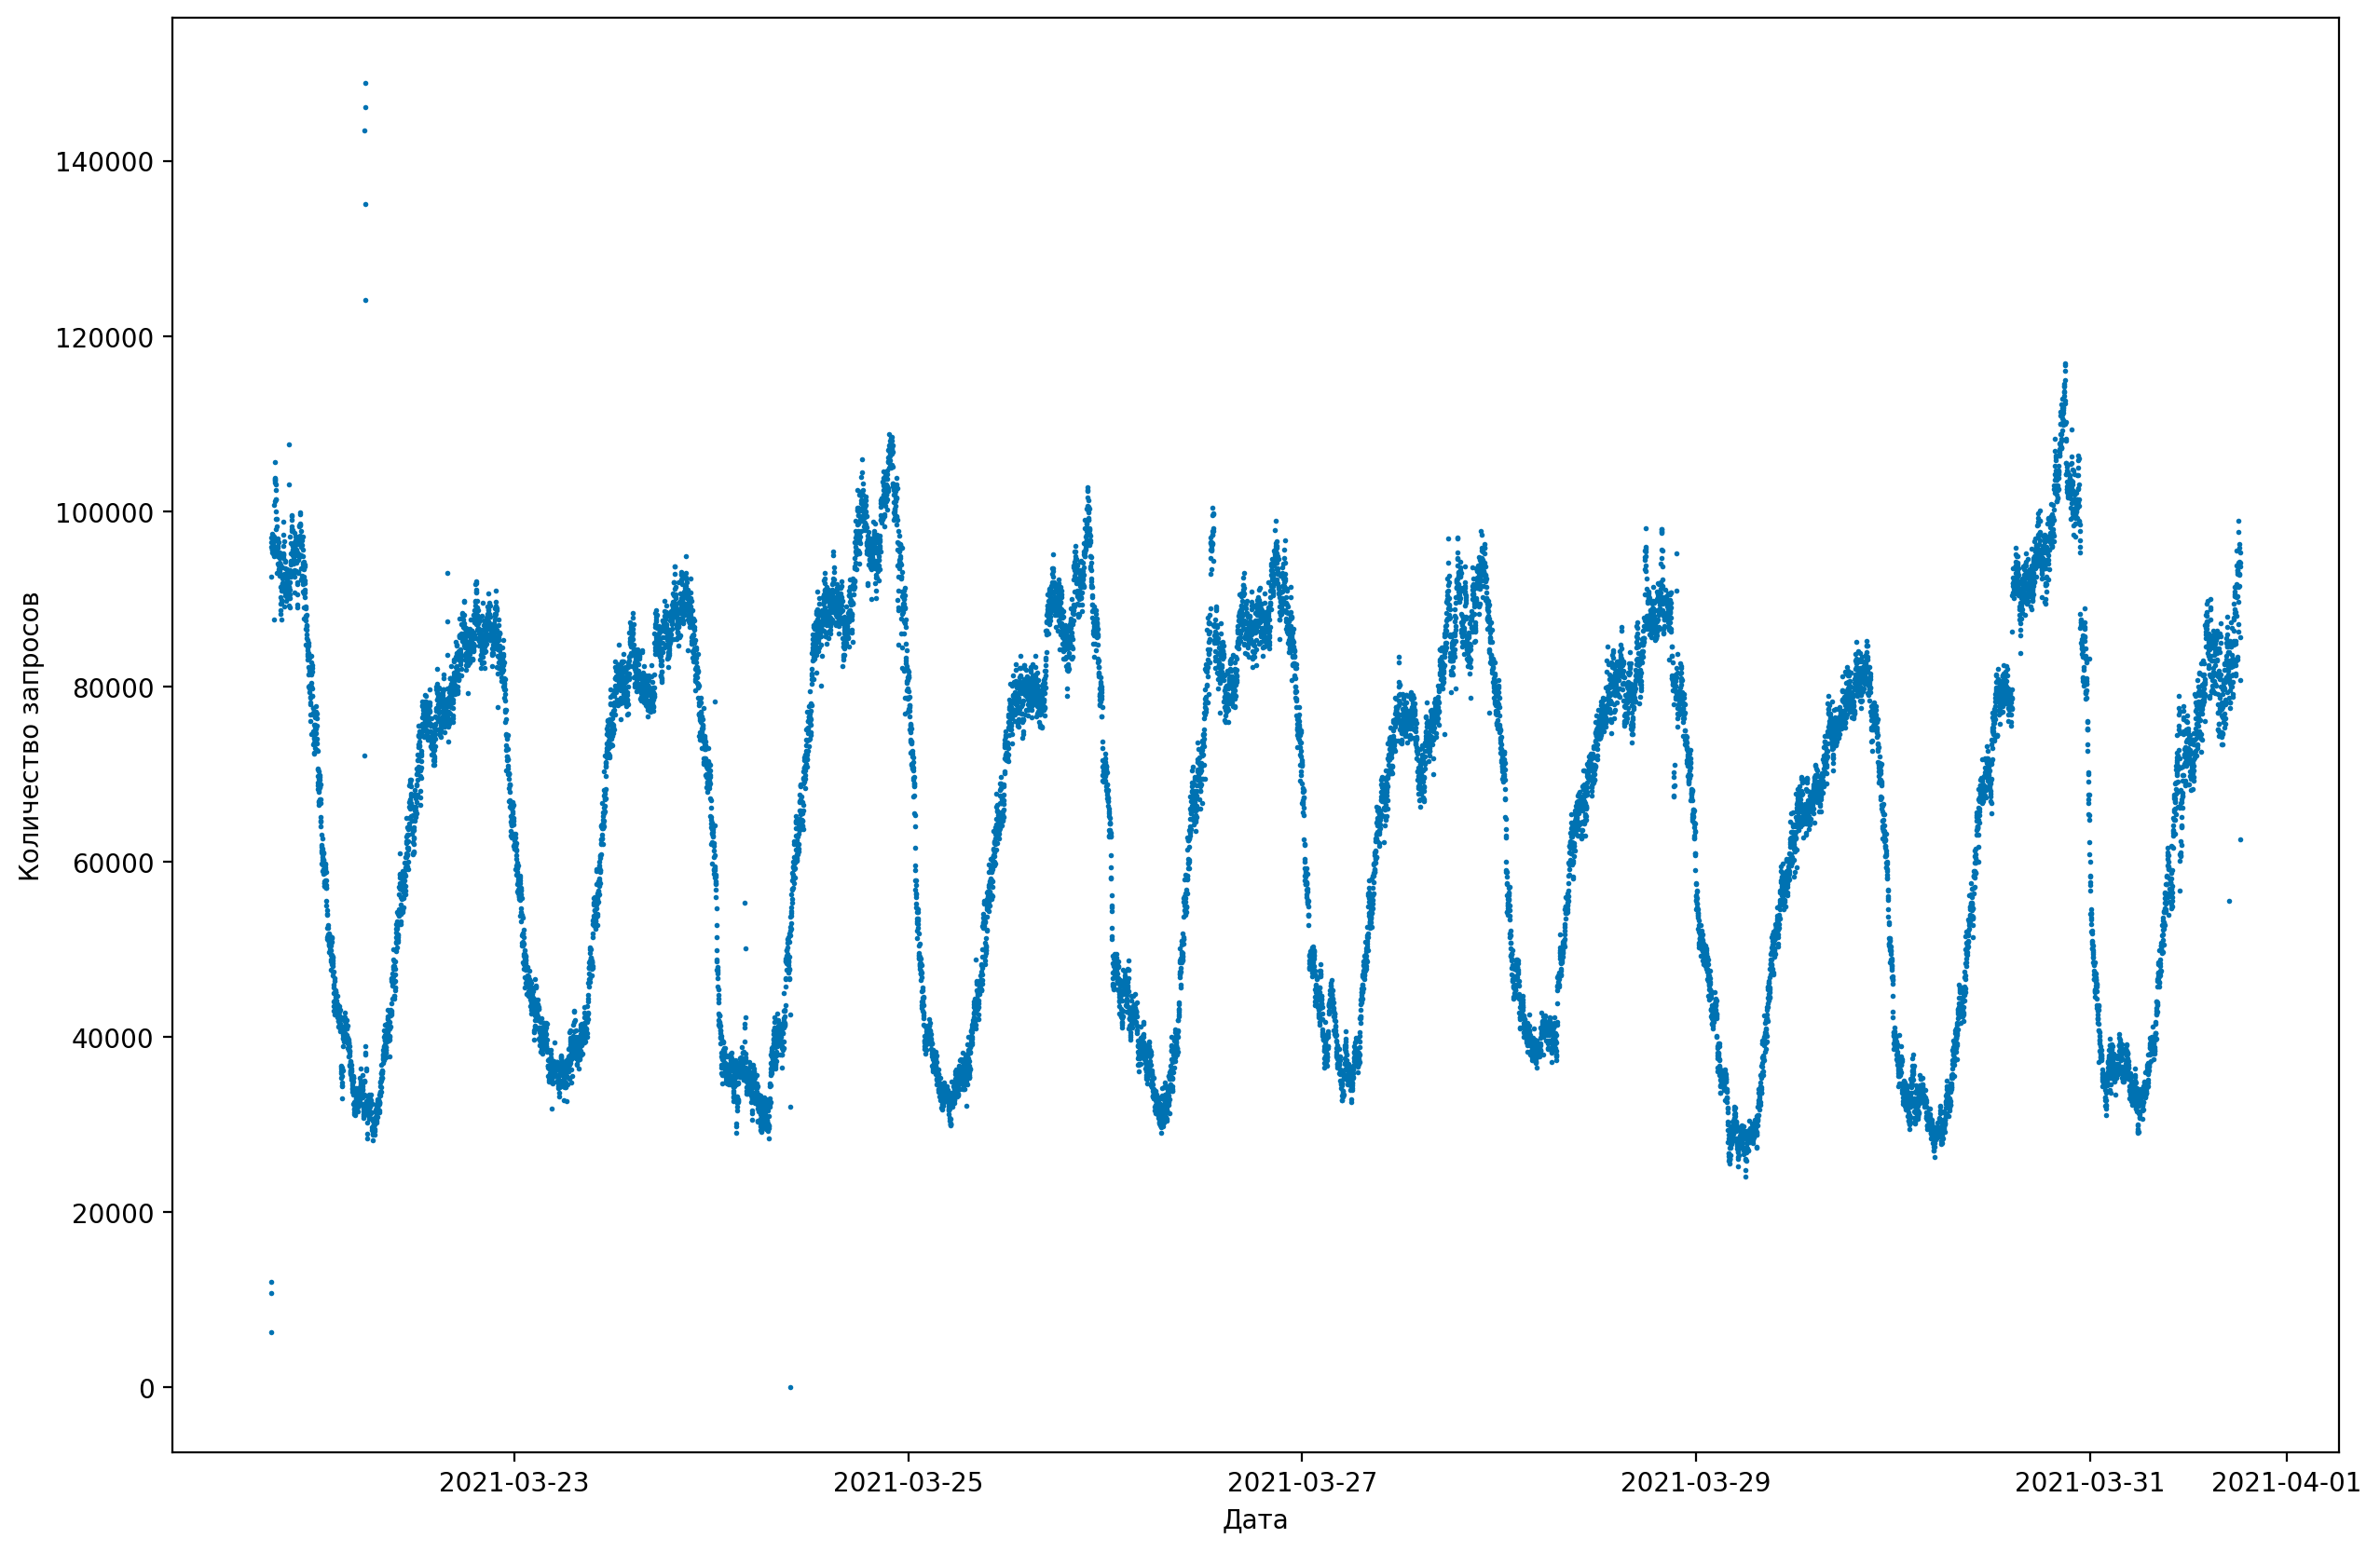

In [ ]:
# визуализируем временной ряд
plt.figure(figsize=(15, 10))
plt.scatter(pd.to_datetime(data_minutes['ds']),
            data_minutes['y'],
            s=1,
            c='#0072B2')
plt.xlabel('Дата')
plt.ylabel(r'Количество запросов')
plt.show()

### Модель Prophet

In [ ]:
model = Prophet(seasonality_mode='additive', n_changepoints=30,
                changepoint_range=1.0)

model.fit(data_minutes);

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpd5mzcfoi/7t1121vj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpd5mzcfoi/9zr3t5f4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=83032', 'data', 'file=/tmp/tmpd5mzcfoi/7t1121vj.json', 'init=/tmp/tmpd5mzcfoi/9zr3t5f4.json', 'output', 'file=/tmp/tmpd5mzcfoi/prophet_model_rw3cli4/prophet_model-20250227054706.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:47:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:47:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# получаем удлиненный датафрейм, задав горизонт прогнозирования - 2 минуты
future = model.make_future_dataframe(periods=2, freq='T')

In [ ]:
# получаем прогнозы
forecast = model.predict(future)

Text(0.5, 1.0, 'Количество запросов')

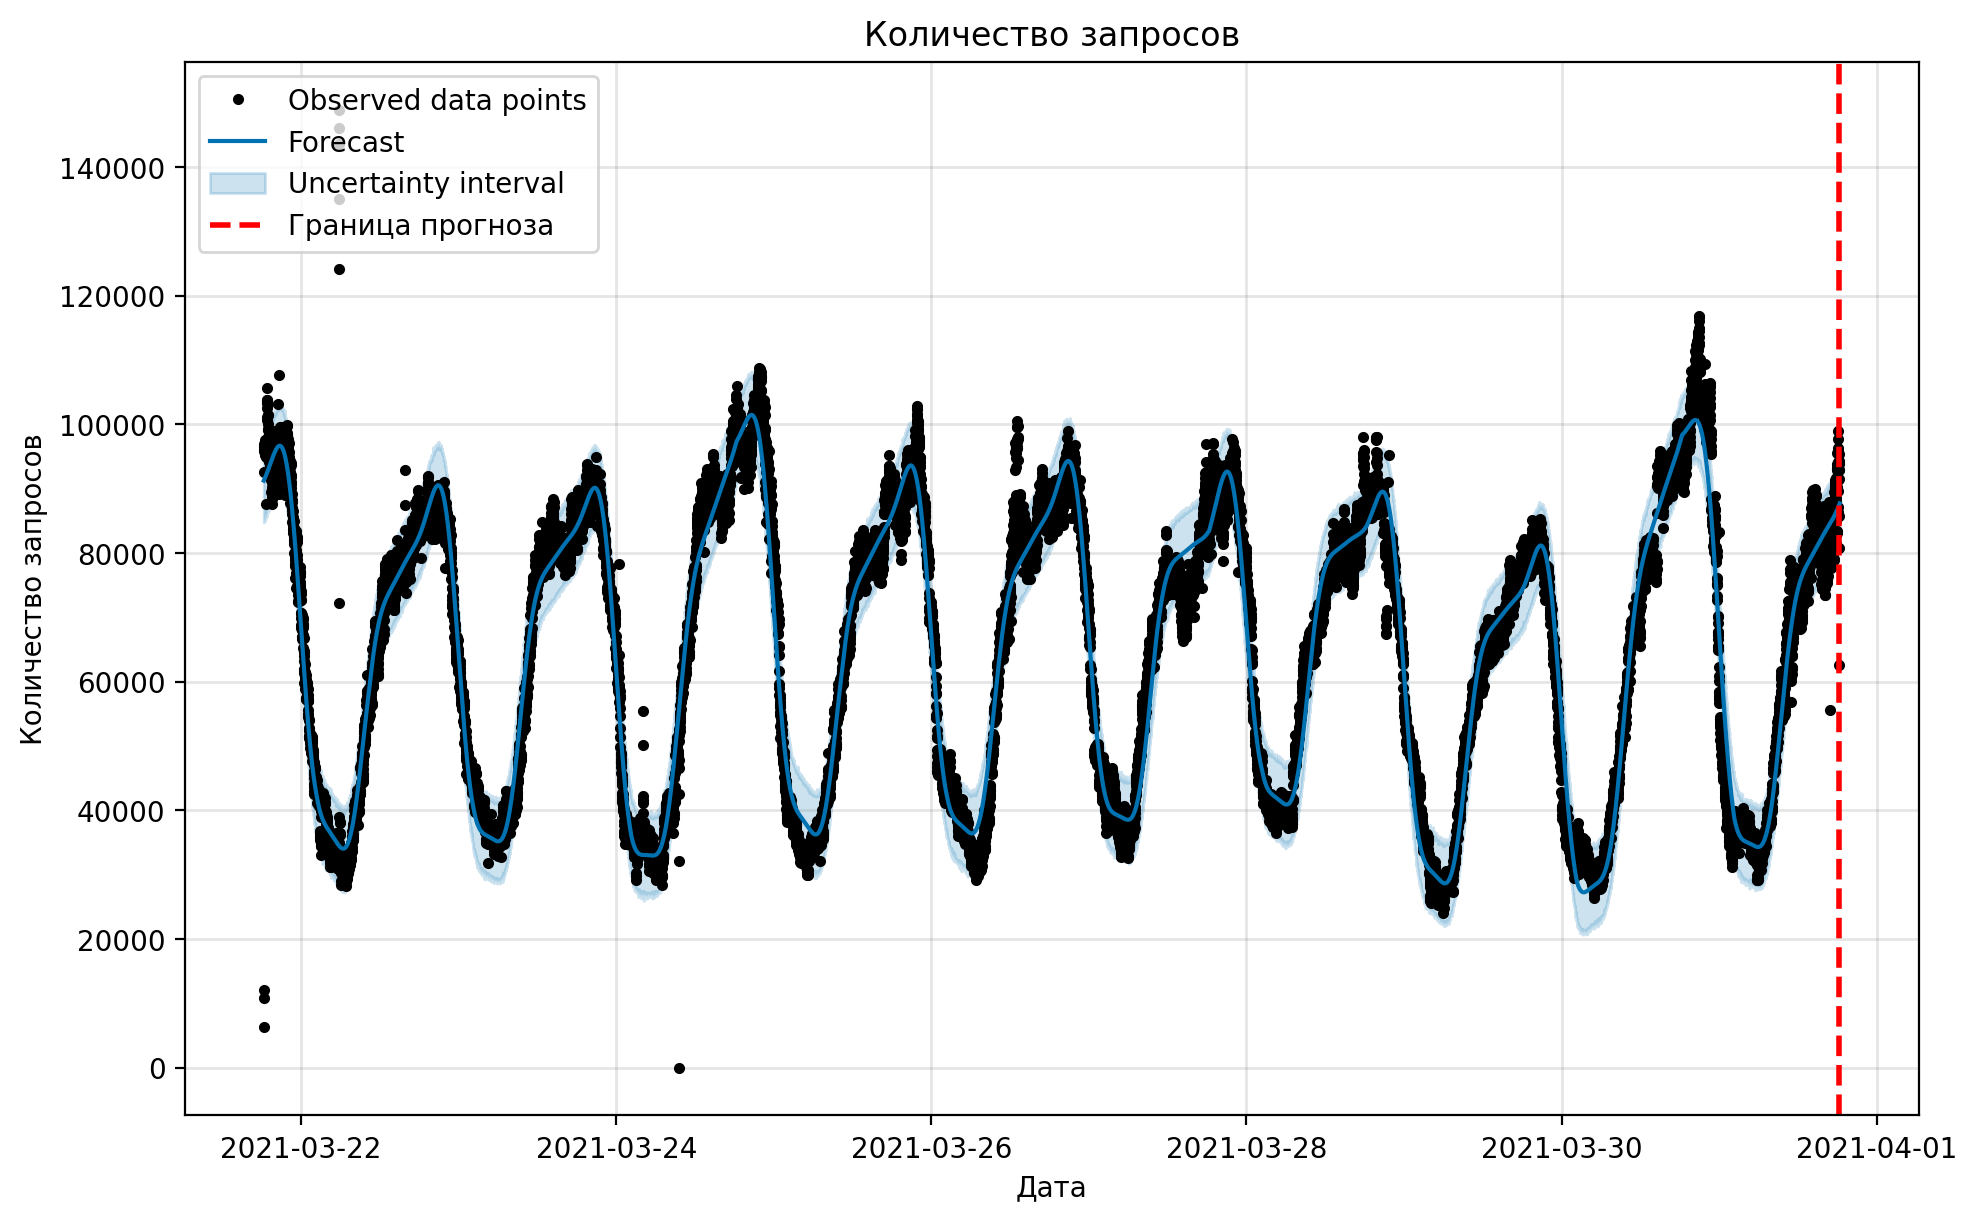

In [ ]:
# Визуализируем прогнозы
fig = model.plot(forecast, xlabel='Дата', ylabel='Количество запросов')

# Добавляем четкое разграничение между train и прогнозом
# Находим последнюю дату из исторических данных
last_train_date = data_minutes['ds'].max()

# Добавляем вертикальную линию для разделения train и прогноза
plt.axvline(x=last_train_date, color='red', linestyle='--', linewidth=2, label='Граница прогноза')

# Добавляем легенду
plt.legend(loc='upper left')

# Добавляем заголовок
plt.title('Количество запросов')

In [ ]:
# смотрим первые 2 прогноза
forecast.head(2).T

,0,1
ds,2021-03-21 18:18:00,2021-03-21 18:19:00
trend,70149.528504,70143.54189
yhat_lower,85418.156869,84720.093508
yhat_upper,97823.839521,97270.676483
trend_lower,70149.528504,70143.54189
trend_upper,70149.528504,70143.54189
additive_terms,21093.13441,21135.272536
additive_terms_lower,21093.13441,21135.272536
additive_terms_upper,21093.13441,21135.272536
daily,21093.13441,21135.272536


Разложение временного ряда на тренд и сезонность

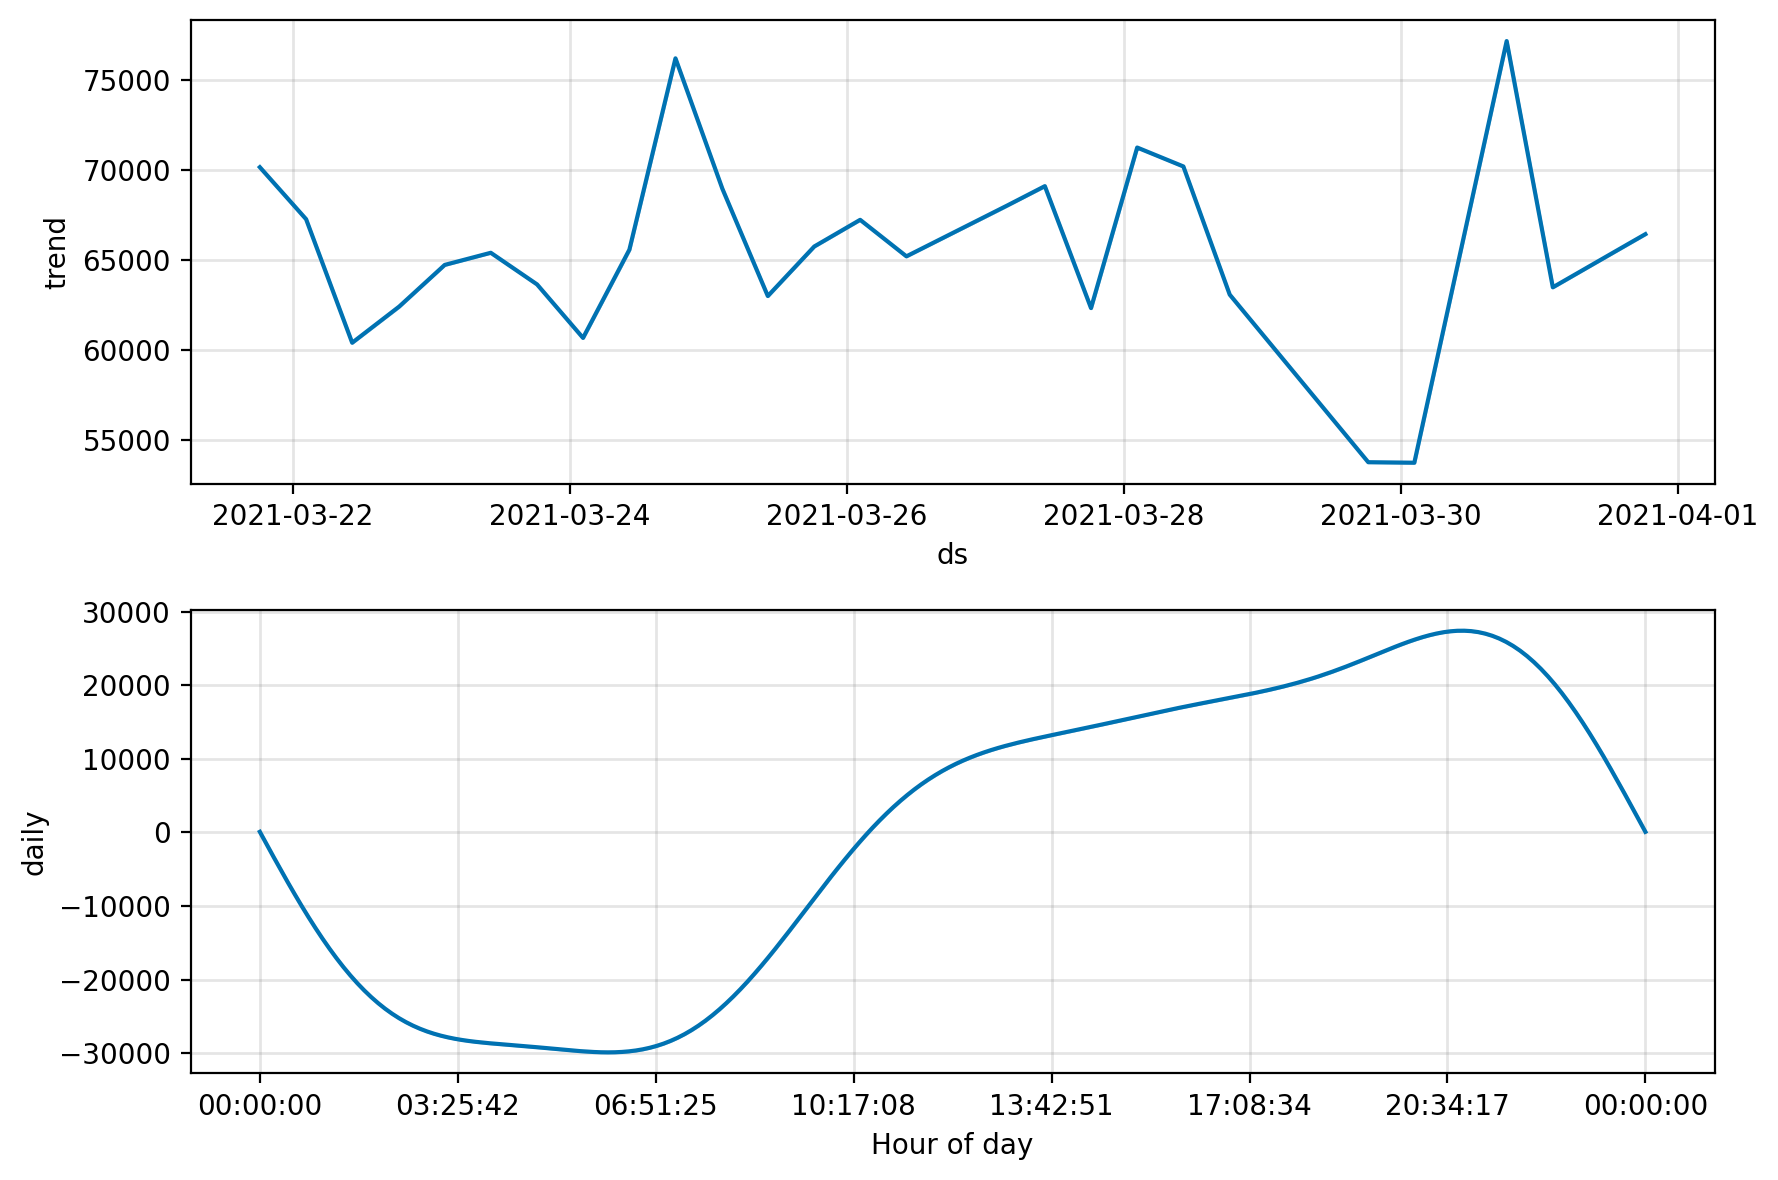

In [ ]:
fig2 = model.plot_components(forecast)
plt.show()

Верхний график: Тренд (trend)

- Диапазон дат: с 22 марта 2021 года по 1 апреля 2021 года.
- Общий вид: Тренд показывает общую динамику временного ряда в течение этого периода. Мы видим колебания, но в целом можно отметить некоторую нестабильность.
- Особенности:
 - Резкий скачок вверх примерно 24 марта 2021 года.
 - Значительное падение примерно 29-30 марта 2021 года.
 - Восстановление после падения.
- Интерпретация: Тренд демонстрирует, что в течение рассматриваемого периода наблюдались значительные изменения в общем уровне данных. Возможно, это связано с внешними факторами, такими как экономические события, изменения в поведении пользователей или другие события, влияющие на данные.

Нижний график: Дневная сезонность (daily)

- Ось X: Время суток (от 00:00:00 до 00:00:00 следующего дня).
- Общий вид: График показывает, как значения временного ряда меняются в течение дня.
- Особенности:
 - Ярко выраженный U-образный паттерн.
 - Минимум приходится на ранние утренние часы (около 03:25:42).
 - Максимум приходится на вечерние часы (около 20:34:17).
- Интерпретация:
 - Этот график указывает на сильную дневную сезонность в данных.
 - Значения значительно ниже среднего утром, постепенно растут в течение дня и достигают пика вечером.
 - Это может указывать на активность, связанную с рабочим днем или периодами наибольшей активности пользователей (например, использование онлайн-сервиса).
- Общие выводы

 - Комбинация тренда и дневной сезонности: Общее значение временного ряда в любой момент времени будет зависеть от комбинации тренда и дневной сезонности. Например, даже если тренд растет в определенный день, фактическое значение утром может быть ниже из-за дневной сезонности.

Для улучшения прогноза модели Prophet найдем точки изменения тренда временного ряда. Найдем 30 потенциальных точек изменения тренда и визуализируем их в как вертикальные пунктирные линии

In [ ]:
# пишем функцию, задающую точки изменения тренда
def set_changepoints(df, n_changepoints, changepoint_range):
    """
    Задает точки изменения
    """
    df = df.sort_values('ds').reset_index(drop=True)
    # равномерно размещаем потенциальные точки изменения
    # в первых `changepoint_range` процентах наблюдений
    # исторической выборки
    hist_size = int(np.floor(df.shape[0] * changepoint_range))
    if n_changepoints + 1 > hist_size:
        n_changepoints = hist_size - 1
        print('n_changepoints больше количества' +
              'наблюдений. Используем {}.'.format(n_changepoints))
    if n_changepoints > 0:
        cp_indexes = np.linspace(0,
                                 hist_size - 1,
                                 n_changepoints + 1).round().astype(int)
        changepoints = df.iloc[cp_indexes]['ds'].tail(-1)
    else:
        # задаем пустые точки изменения
        changepoints = pd.Series(pd.to_datetime([]), name='ds')
    return changepoints

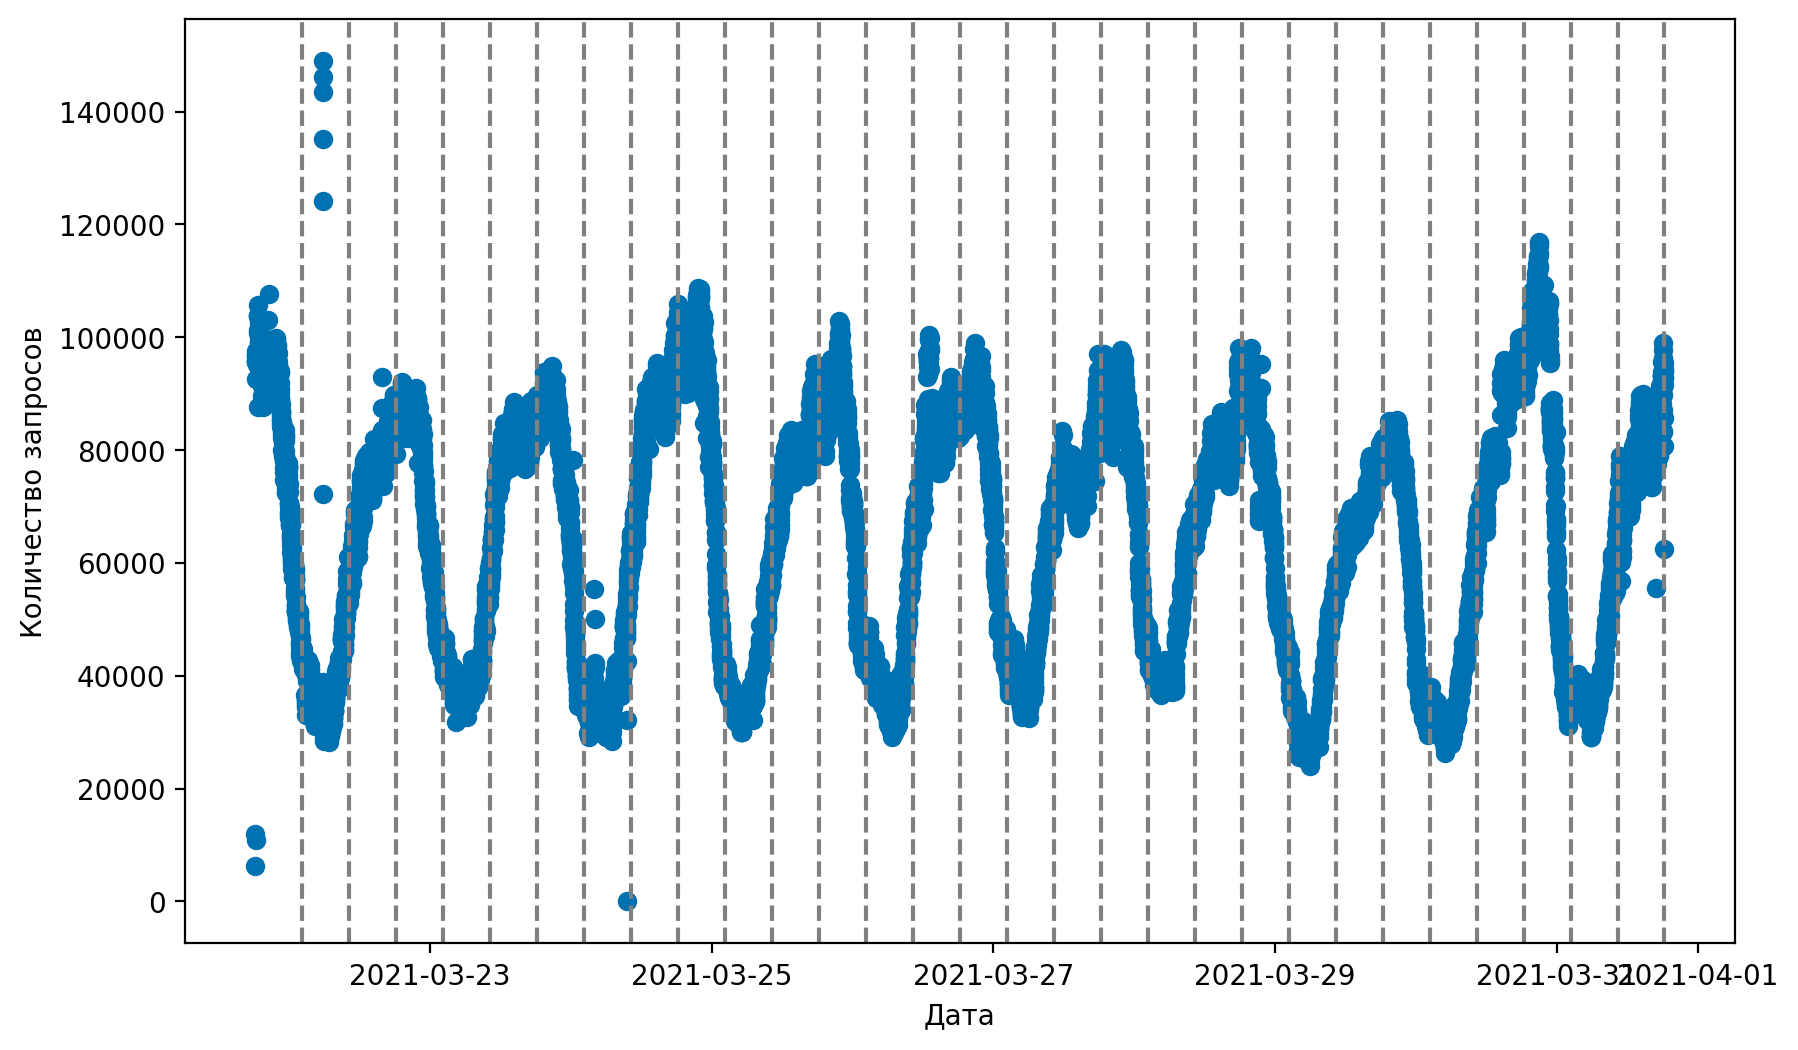

In [ ]:
# создаем 30 потенциальных точек изменения
# в первых 80% исторических данных
changepoints = set_changepoints(data_minutes, 30, 1.0)

# визуализируем точки изменения
plt.figure(figsize=(10, 6))
plt.scatter(data_minutes['ds'], data_minutes['y'], c='#0072B2')
for cp in changepoints:
    plt.axvline(x=cp, c='gray', ls='--')
plt.xlabel('Дата')
plt.ylabel('Количество запросов')
plt.show()

Модель Prophet самостоятельно определяет величину потенциальных точек изменения тренда.  Визуализируем точки изменения тренда ранее обученной модели Prophet

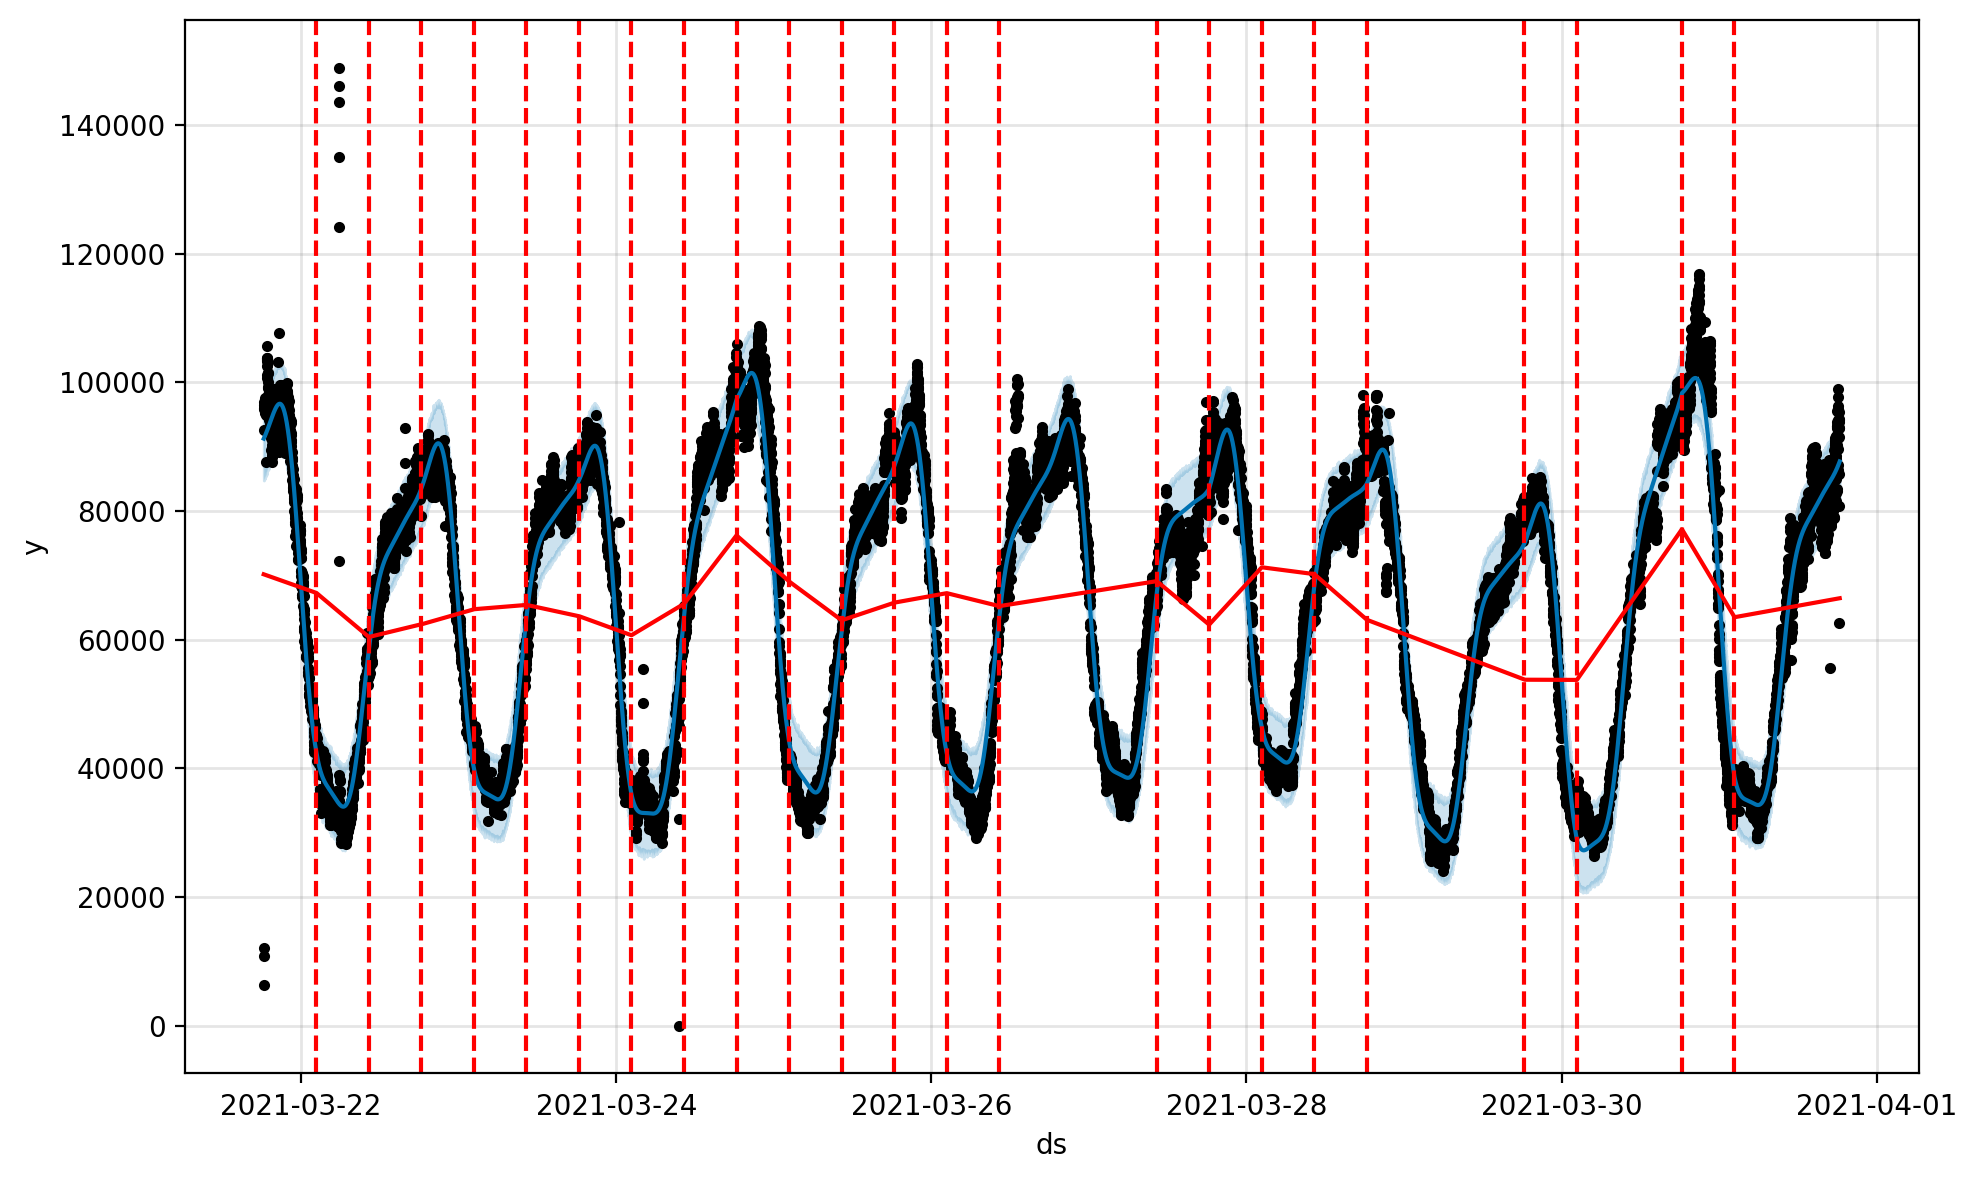

In [ ]:
# визуализируем прогнозы
fig = model.plot(forecast)

# наносим точки изменения
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()
plt.show()

## Выявление и удаление выбросов и аномальных значений в данных


Изменение гиперпараметров модель Prophet:

1. Ширину интервалов неопределенности (по умолчанию 80%) можно задать с помощью параметра interval_width. Увеличиваем доверительный интервал изменив ширину интервала неопределлености  interval_width=1.0

2. По умолчанию точки изменения тренда выводятся только для первых 80% временного ряд. Изменим параметр changepoint_range=1.0 для включения всего диапазона данных для вывода точек изменения тренда

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpd5mzcfoi/si02ohnt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpd5mzcfoi/y34fbq6r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80573', 'data', 'file=/tmp/tmpd5mzcfoi/si02ohnt.json', 'init=/tmp/tmpd5mzcfoi/y34fbq6r.json', 'output', 'file=/tmp/tmpd5mzcfoi/prophet_model36fkjkbw/prophet_model-20250227054749.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:47:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:47:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


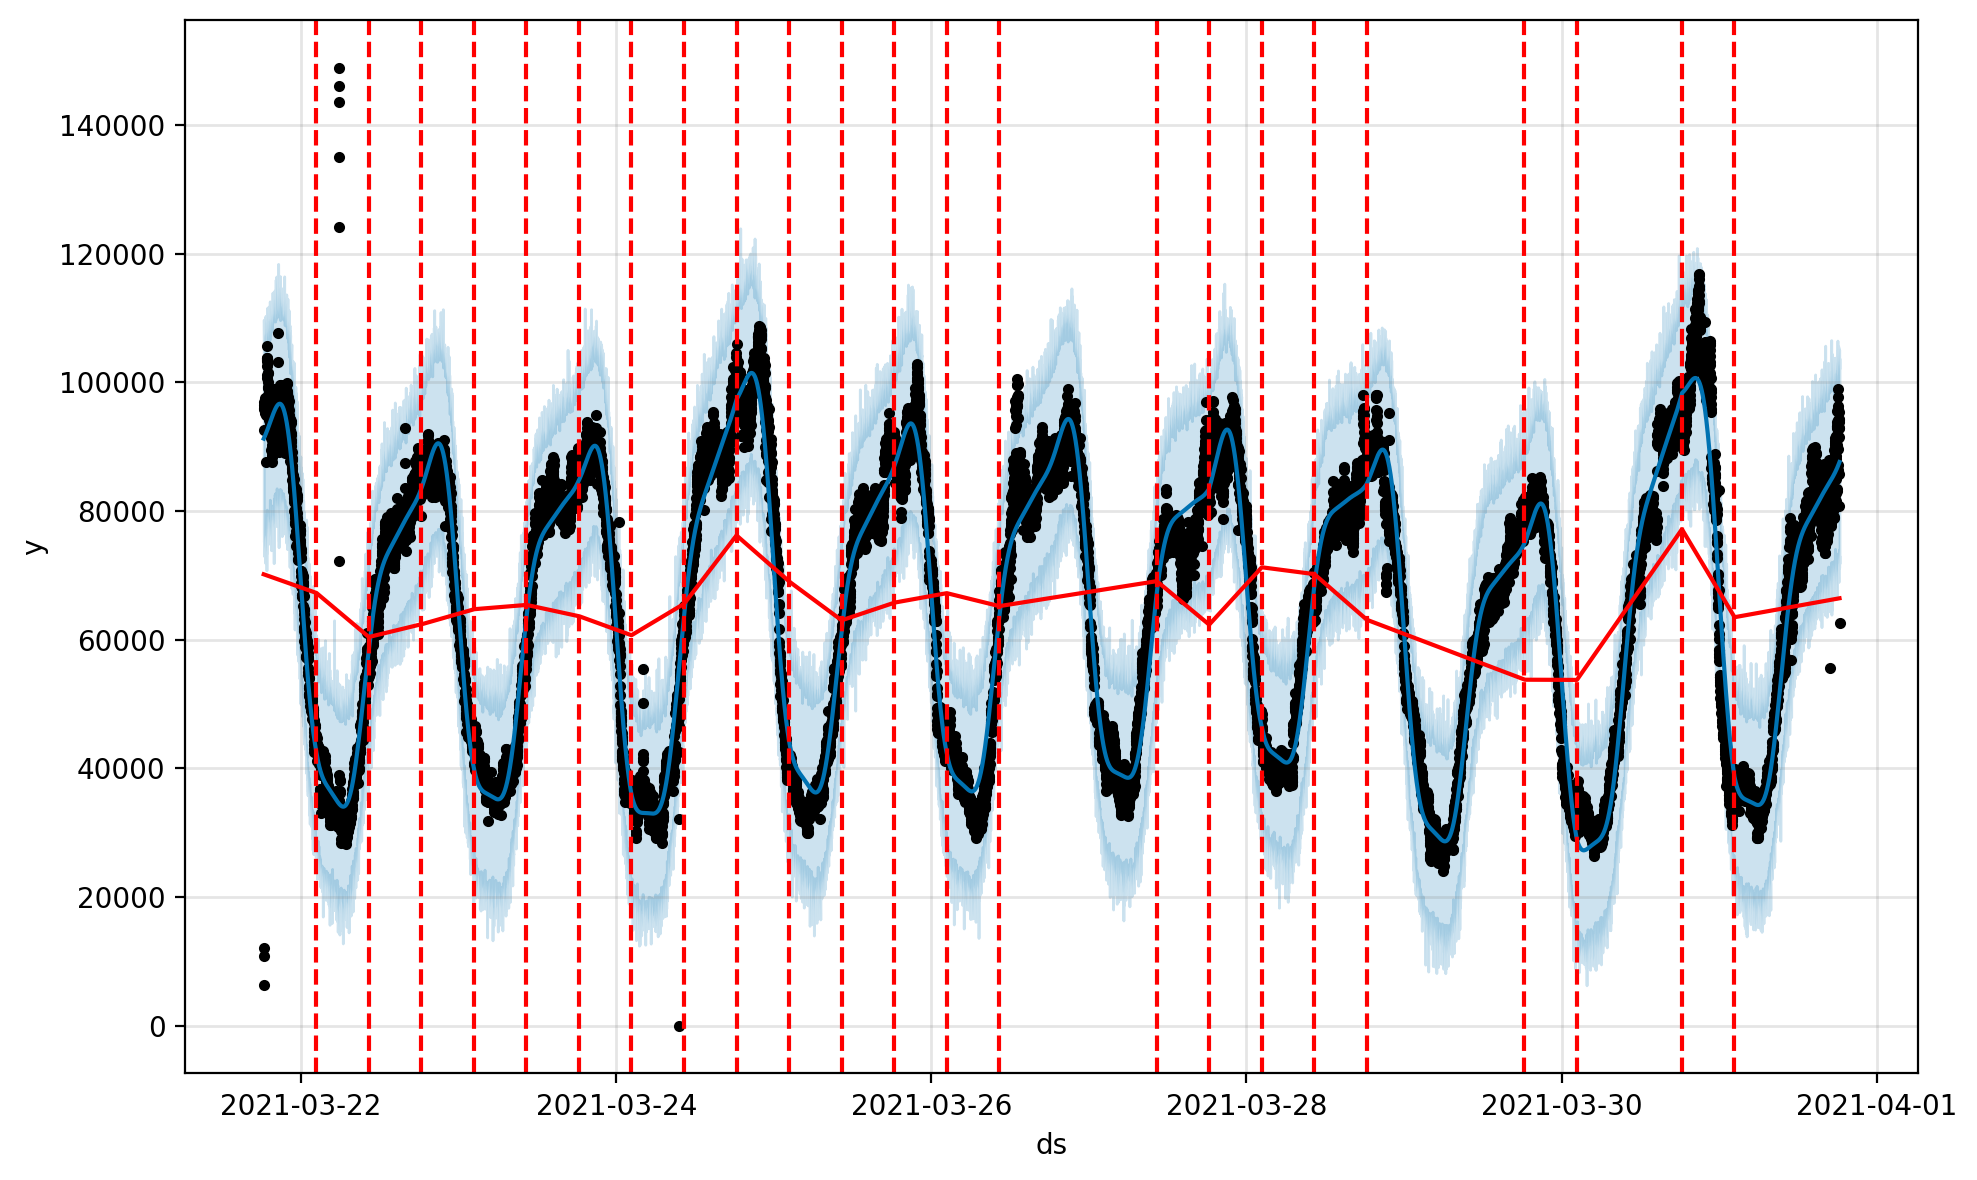

In [ ]:
model = Prophet(seasonality_mode='additive',
                changepoint_range=1.0,
                n_changepoints=30,
                interval_width=1.0)
# обучаем модель
model.fit(data_minutes)
# получаем прогнозы для обучающих данных
forecast = model.predict()
# визуализируем прогнозы
fig = model.plot(forecast)
# наносим точки изменения
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()

### Применение метода скользящего среднего и модели  Prophet для выявления выбросов и аномальных значений в данных

In [ ]:
# Функция для поиска аномалий с помощью метода скользящего среднего
def find_moving_average_anomalies(df, window_size=1440, std_multiplier=1.65):
    """
    Находит аномалии в DataFrame с помощью метода скользящего среднего.

    Args:
        df (pd.DataFrame): Входной DataFrame со столбцами 'ds' и 'y'.
        window_size (int): Размер скользящего окна.
        std_multiplier (float): Количество стандартных отклонений, используемых в качестве порога.

    Returns:
        pd.DataFrame: DataFrame с добавленными столбцами 'moving_average', 'std_dev', 'lower', 'upper' и 'anomaly'.
    """
    df = df.copy()

    df['moving_average'] = df['y'].rolling(window=window_size, min_periods=1, center=True).mean()
    df['std_dev'] = df['y'].rolling(window=window_size, min_periods=1, center=True).std()
    df['lower'] = df['moving_average'] - std_multiplier * df['std_dev']
    df['upper'] = df['moving_average'] + std_multiplier * df['std_dev']
    df['anomaly'] = ((df['y'] < df['lower']) | (df['y'] > df['upper'])).astype(int)

    return df

# Функция для поиска аномалий с помощью Prophet
def find_prophet_anomalies(df, changepoint_range=1.0, n_changepoints=30, interval_width=1.0):
  """
    Находит аномалии в DataFrame с помощью метода Prophet.

    Args:
        df (pd.DataFrame): Входной DataFrame со столбцами 'ds' и 'y'.
        changepoint_range (float): changepoint_range.
        n_changepoints (int): n_changepoints.
        interval_width (float): interval_width.

    Returns:
        pd.DataFrame: DataFrame с добавленными столбцами 'yhat_lower', 'yhat_upper' и 'anomaly'.
    """
  model = Prophet(seasonality_mode='additive',
                changepoint_range=changepoint_range,
                n_changepoints=n_changepoints,
                interval_width=interval_width)
  model.fit(df)
  forecast = model.predict()
  df['yhat_lower'] = forecast['yhat_lower']
  df['yhat_upper'] = forecast['yhat_upper']
  df['anomaly'] = ((df['y'] < df['yhat_lower']) | (df['y'] > df['yhat_upper'])).astype(int)

  return df

# Функция для визуализации данных временных рядов и аномалий
def visualize_anomalies(df_original, df_anomalies, title):
    """
    Визуализирует данные временных рядов и аномалии.

    Args:
        df_original (pd.DataFrame): Исходный DataFrame со столбцами 'ds' и 'y'.
        df_anomalies (pd.DataFrame): DataFrame с информацией об аномалиях.
        title (str): Заголовок графика.
    """
    plt.figure(figsize=(15, 10))
    plt.scatter(df_original['ds'], df_original['y'], s=1, c='#0072B2', label='Нормальные Данные')
    plt.scatter(df_anomalies.loc[df_anomalies['anomaly'] == 1, 'ds'], df_anomalies.loc[df_anomalies['anomaly'] == 1, 'y'], s=20, c='red', label='Аномалии', marker='x')
    plt.xlabel('Дата')
    plt.ylabel('Количество Запросов')
    plt.title(title)
    plt.legend()
    plt.show()

### Визуализация выбросов и аномальных значений в данных методом скользящего среднего

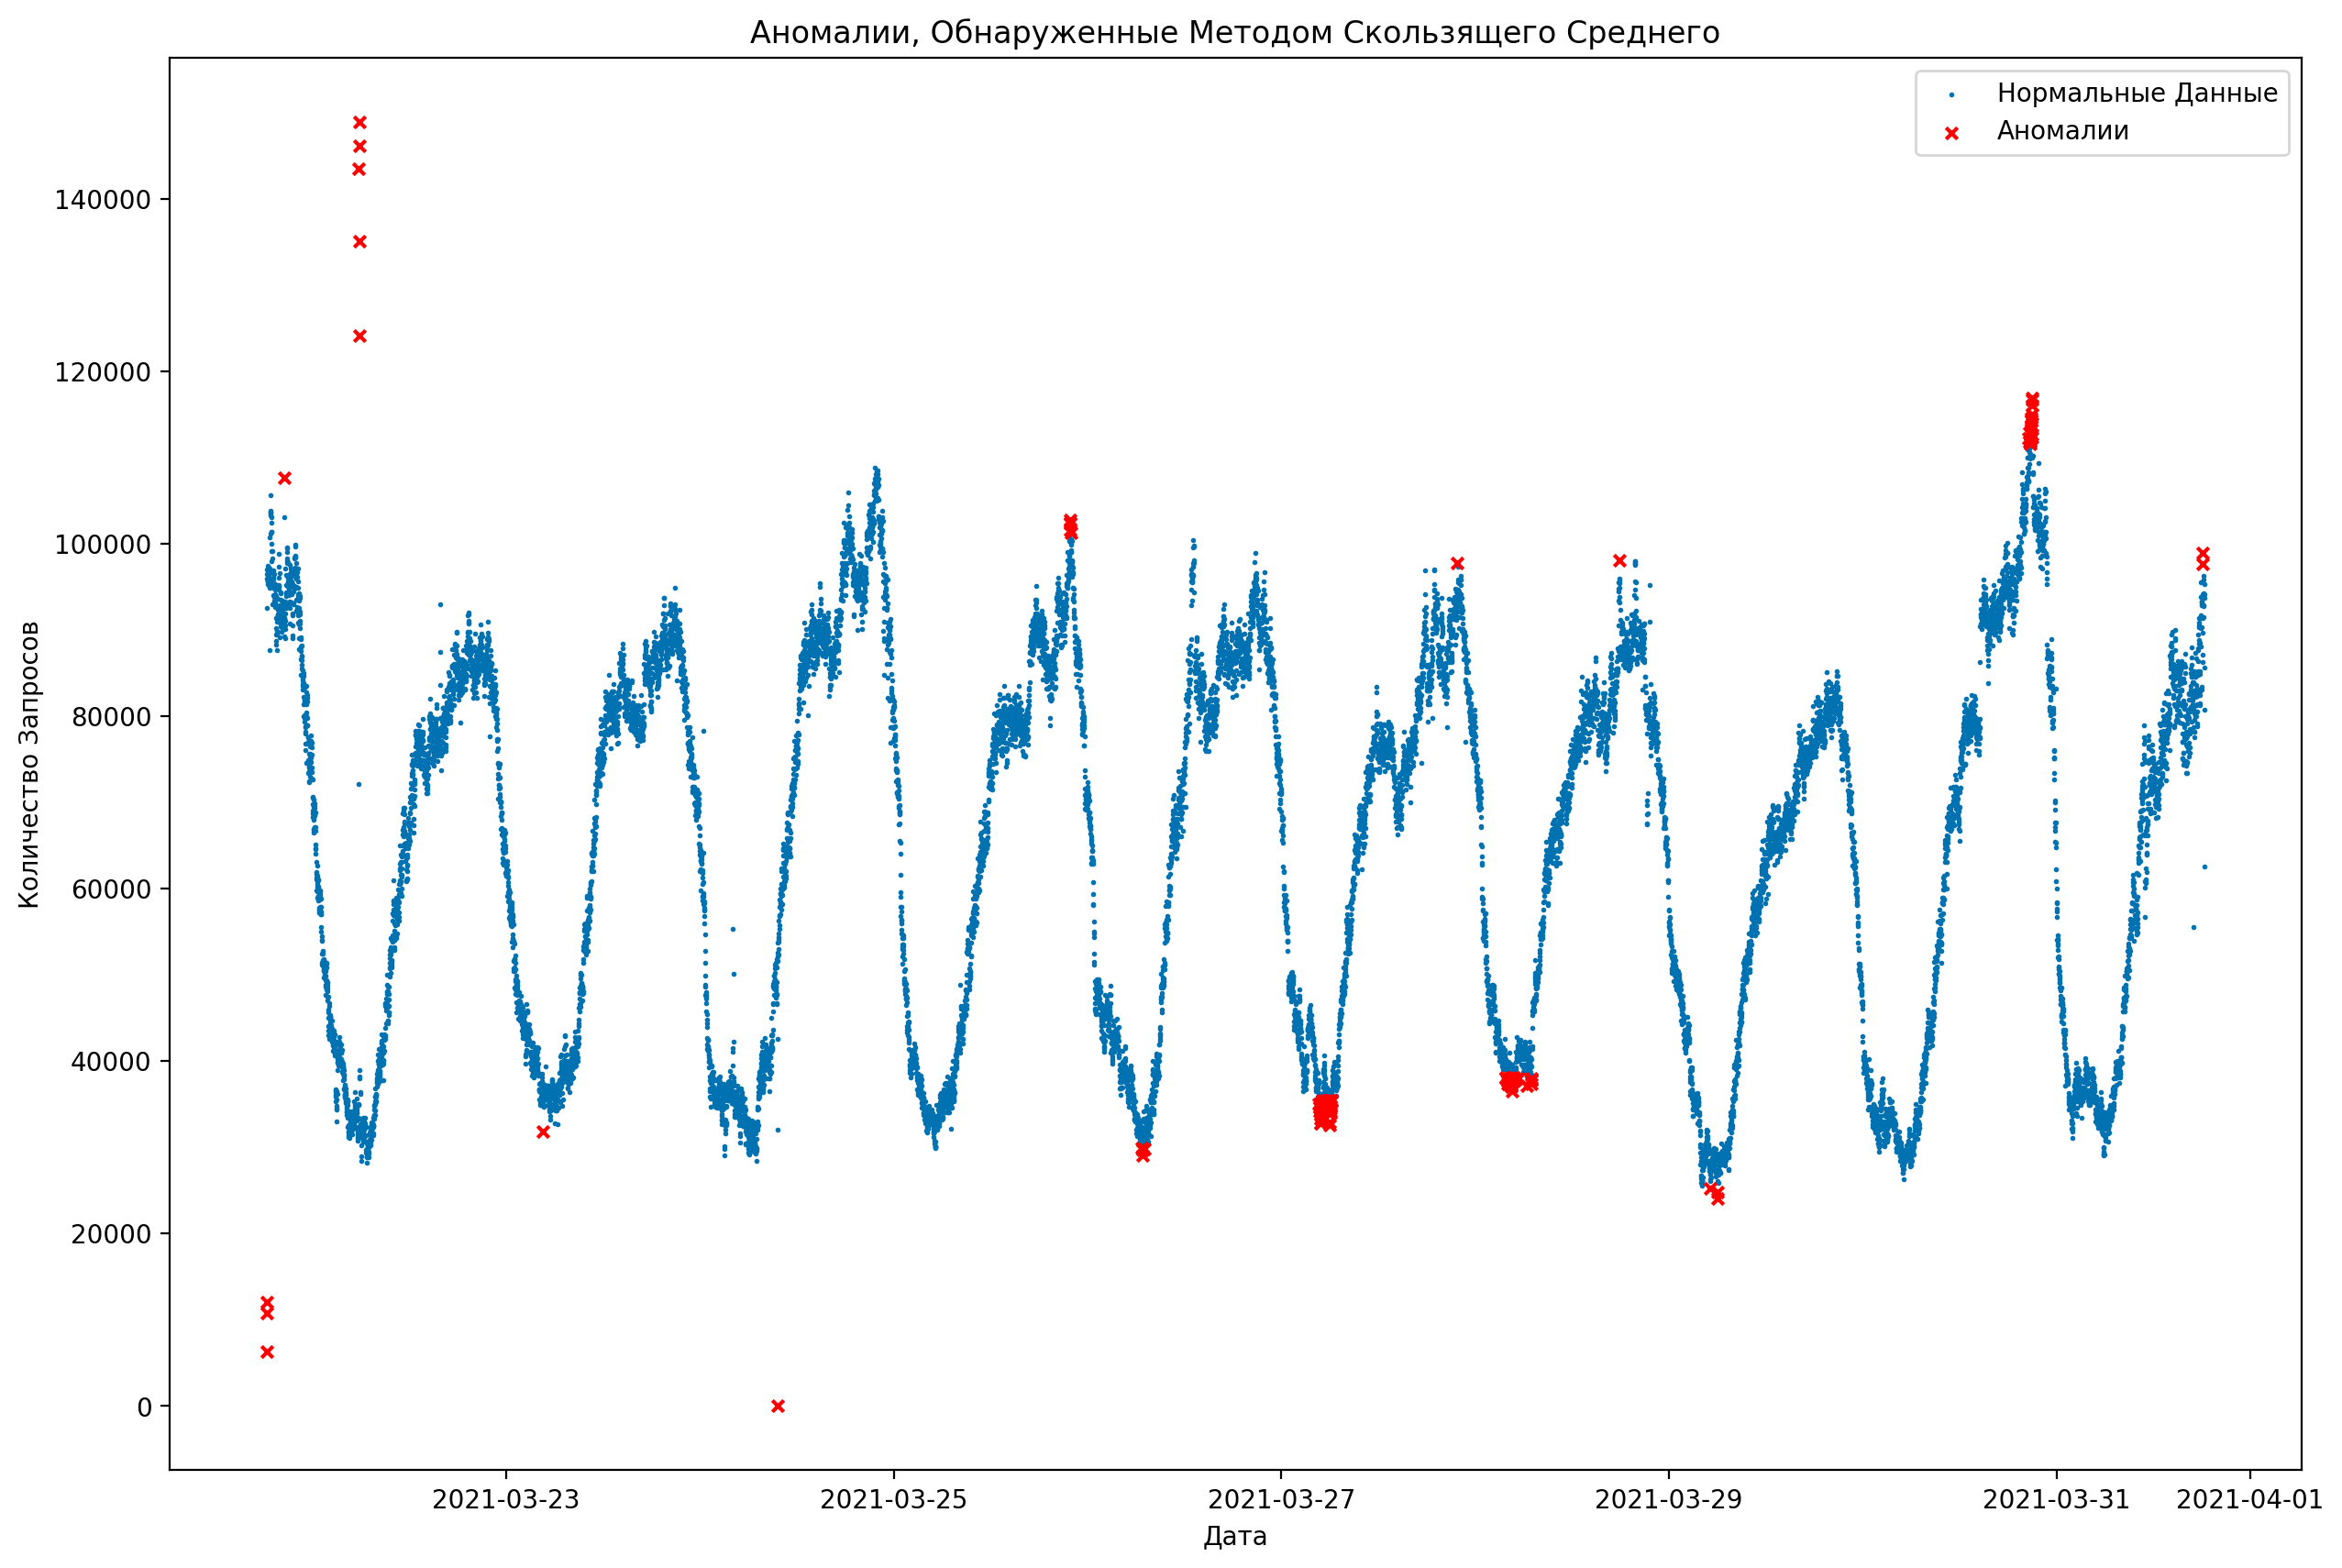

In [ ]:
# Находим аномалии методом скользящего среднего
df_moving_average = find_moving_average_anomalies(data_minutes)

# Визуализируем аномалии методом скользящего среднего
visualize_anomalies(data_minutes, df_moving_average, "Аномалии, Обнаруженные Методом Скользящего Среднего")

Вычисляется верхняя граница как скользящее среднее плюс 1.65 умноженное на скользящее стандартное отклонение.
Коэффициент 1.65: Этот коэффициент соответствует примерно 90% доверительного интервала для нормального распределения. Это означает, что значения, находящиеся за пределами этих границ, считаются аномальными с 10% вероятностью.

### Визуализация выбросов и аномальных значений в данных моделью Prophet.

В модели Prophet для выявления выбросов и аномальных значений в данных используется доверительный интервал. Значения превышающие нижнии и верхнии заначения доверительного интервала (yhat_lower и yhat_upper) соответственно,  классифицируются как аномальные.


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/pxv7ivs4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/yvd7kk5g.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=23496', 'data', 'file=/tmp/tmpg8d4wmti/pxv7ivs4.json', 'init=/tmp/tmpg8d4wmti/yvd7kk5g.json', 'output', 'file=/tmp/tmpg8d4wmti/prophet_modelebmvwj0e/prophet_model-20250226184509.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:45:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:45:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


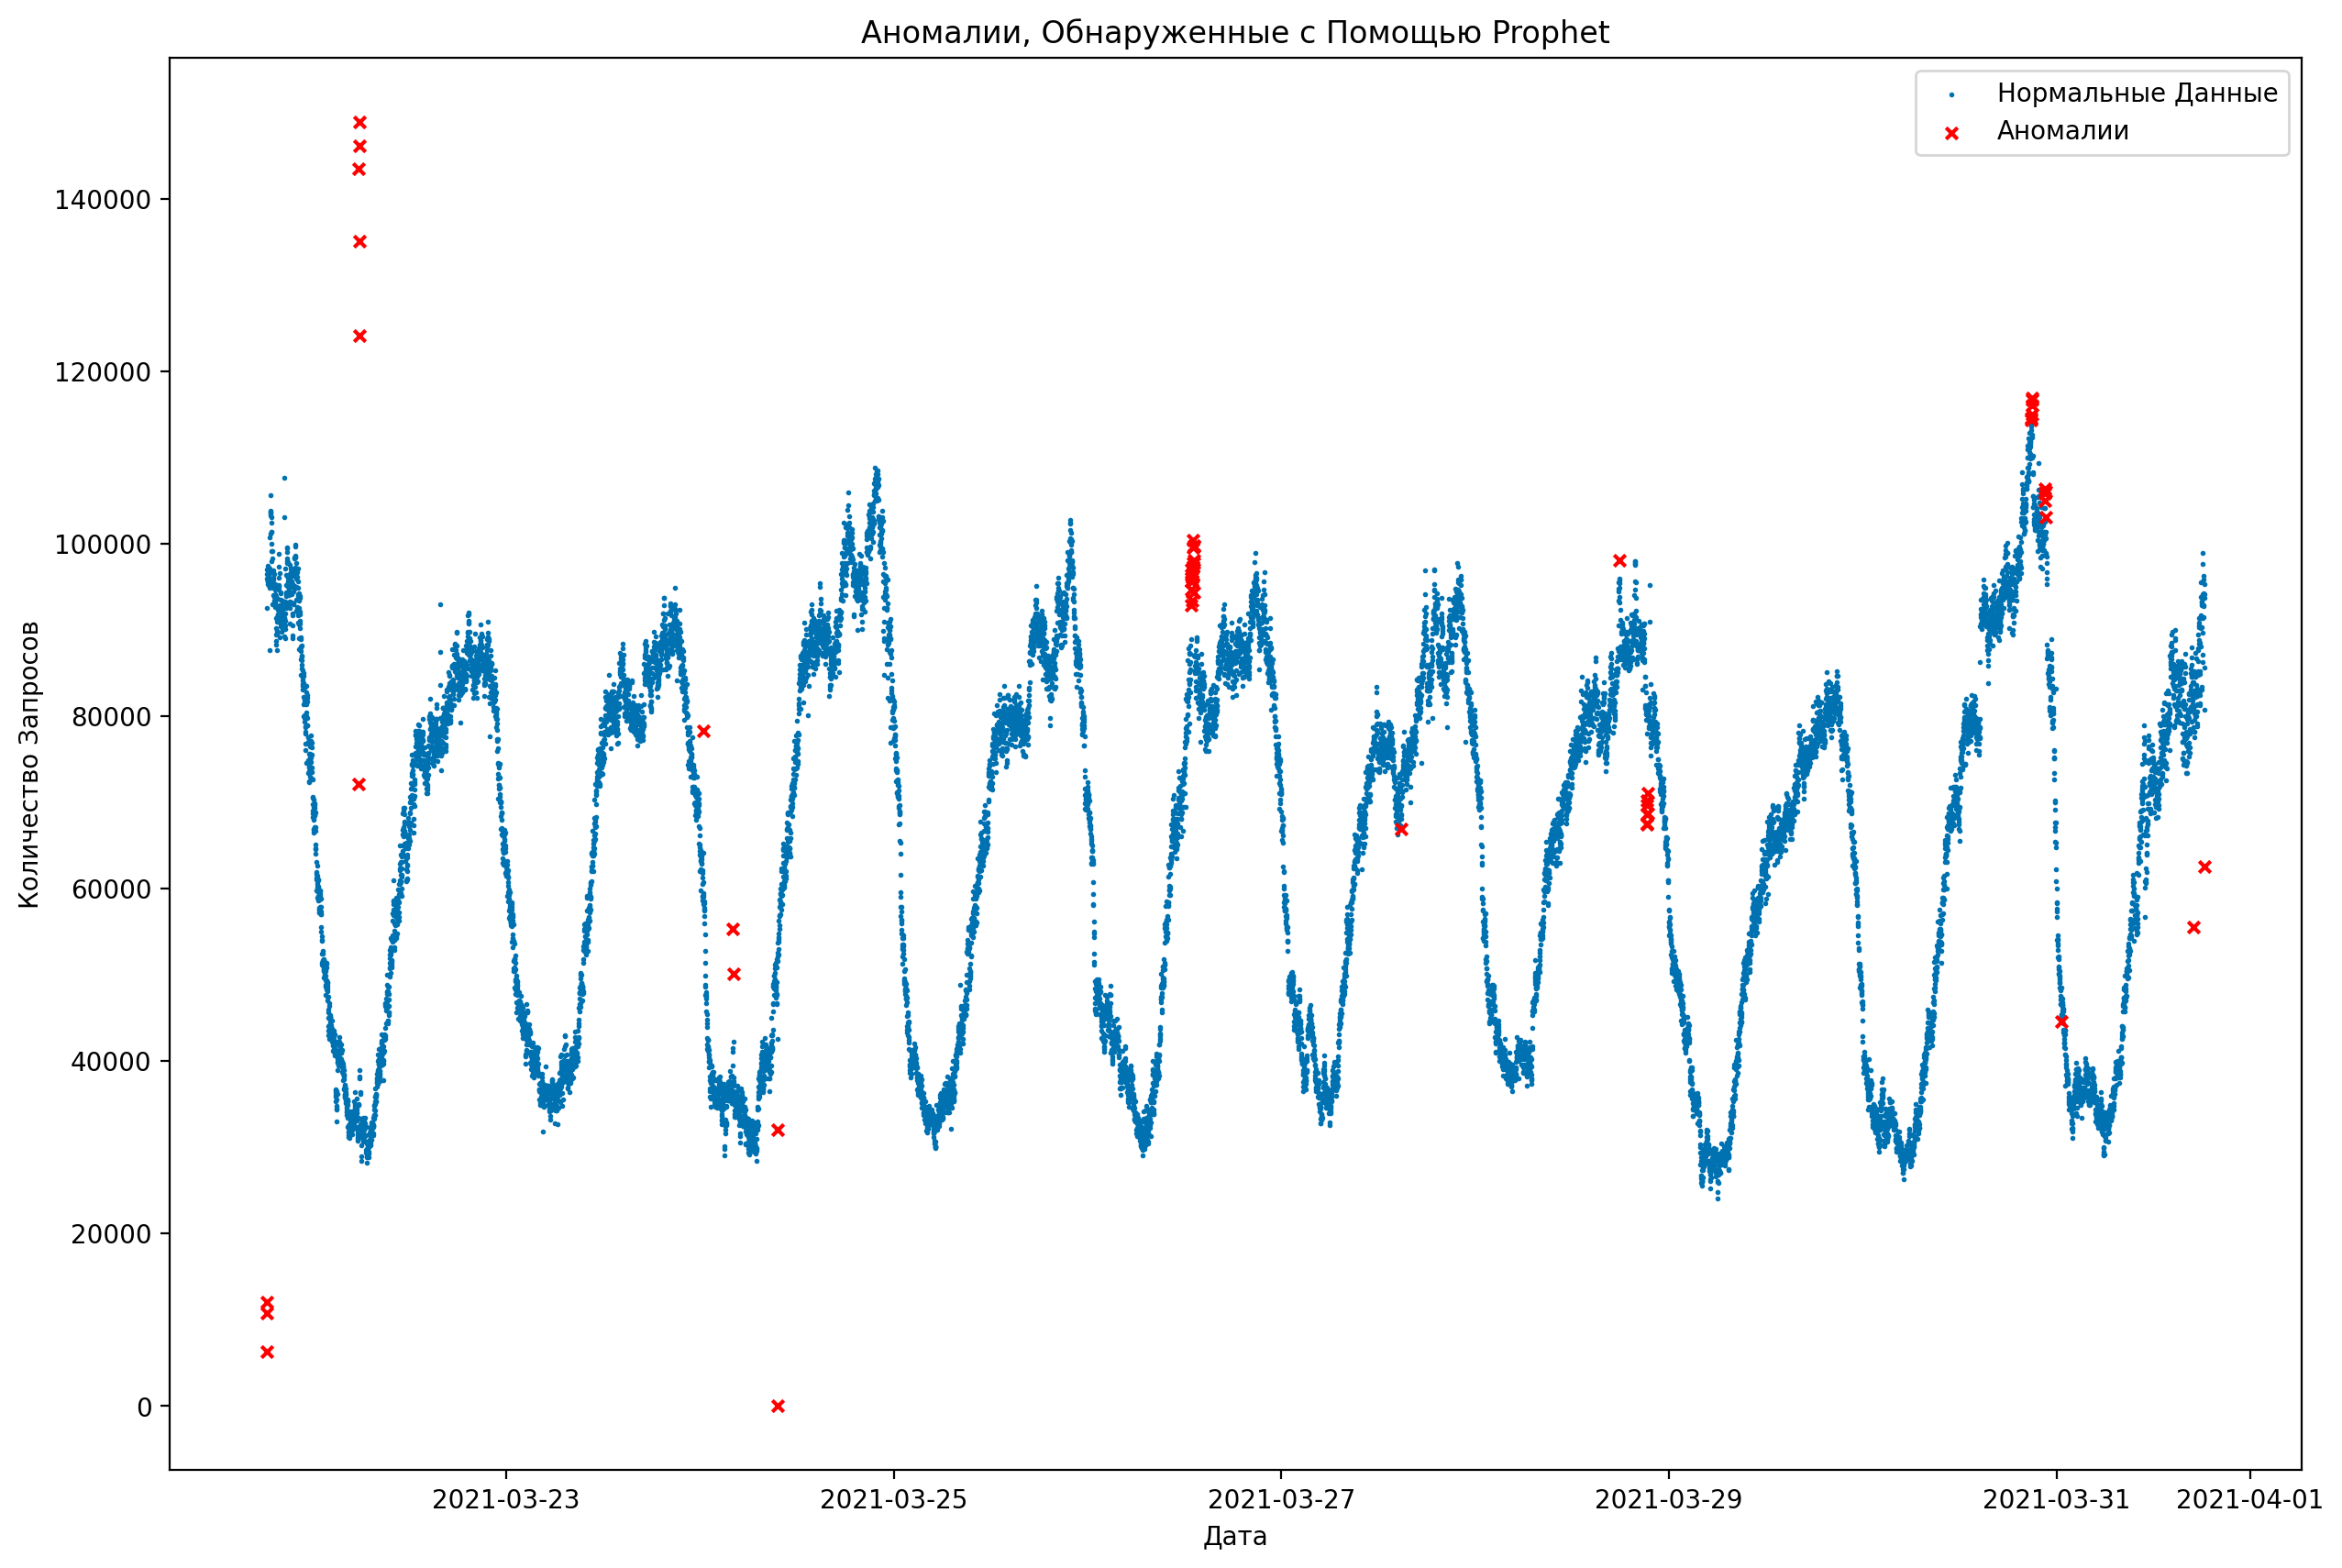

In [ ]:
# Находим аномалии методом prophet
data_minutes_with_anomalies = find_prophet_anomalies(data_minutes.copy())

# Визуализируем аномалии методом prophet
visualize_anomalies(data_minutes, data_minutes_with_anomalies, "Аномалии, Обнаруженные с Помощью Prophet")

### Для удаления выбросов и аномальных значений из данных используем доверительный интервал в модели Prophet

In [ ]:
# Удаление аномалий
data_no_prophet_anomalies = data_minutes_with_anomalies[data_minutes_with_anomalies['anomaly'] == 0].copy()

In [ ]:
data_no_prophet_anomalies

,ds,y,yhat_lower,yhat_upper,anomaly
3,2021-03-21 18:21:00,92523,74117.655032,108388.662420,0
4,2021-03-21 18:22:00,95961,76985.039550,105242.922745,0
5,2021-03-21 18:23:00,96984,75352.374183,108905.874936,0
6,2021-03-21 18:24:00,96463,77005.613606,105185.352552,0
7,2021-03-21 18:25:00,95768,76982.637500,111064.363444,0
...,...,...,...,...,...
14397,2021-03-31 18:15:00,93750,72388.799765,103265.563482,0
14398,2021-03-31 18:16:00,94111,70768.826437,102102.720880,0
14399,2021-03-31 18:17:00,95376,66106.526395,100218.195605,0
14400,2021-03-31 18:18:00,85692,72693.130830,106655.141965,0


In [ ]:
df_save = data_no_prophet_anomalies.drop(columns=['yhat_lower', 'yhat_upper', 'anomaly'])

In [ ]:
df_save

,ds,y
3,2021-03-21 18:21:00,92523
4,2021-03-21 18:22:00,95961
5,2021-03-21 18:23:00,96984
6,2021-03-21 18:24:00,96463
7,2021-03-21 18:25:00,95768
...,...,...
14397,2021-03-31 18:15:00,93750
14398,2021-03-31 18:16:00,94111
14399,2021-03-31 18:17:00,95376
14400,2021-03-31 18:18:00,85692


In [ ]:
df_save.to_csv('/content/drive/MyDrive/Временные ряды_и_книга/data_no_anomalies_new.csv', index=False)

## Модели прогноза с очищенными от аномалий данными

In [ ]:
data_no_anomalies = pd.read_csv('/content/drive/MyDrive/Временные ряды_и_книга/data_no_anomalies_new.csv')

In [ ]:
# Преобразуем столбец 'ds' в формат datetime и сортируем по времени
data_no_anomalies['ds'] = pd.to_datetime(data_no_anomalies['ds'])
data_no_anomalies = data_no_anomalies.sort_values('ds').reset_index(drop=True)

# Проверим данные после преобразования
data_no_anomalies.head()

,ds,y
0,2021-03-21 18:21:00,92523
1,2021-03-21 18:22:00,95961
2,2021-03-21 18:23:00,96984
3,2021-03-21 18:24:00,96463
4,2021-03-21 18:25:00,95768


In [ ]:
duplicates = data_no_anomalies.duplicated(subset=['ds', 'y'])
print(data_no_anomalies[duplicates])

Empty DataFrame
Columns: [ds, y]
Index: []


In [ ]:
# Создание полной временной шкалы с интервалом в 1 минуту
full_time_index = pd.date_range(start=data_no_anomalies['ds'].min(),
                                end=data_no_anomalies['ds'].max(),
                                freq='1T')

# Объединяем данные с полной шкалой времени
data_filled = pd.DataFrame({'ds': full_time_index})
data_filled = data_filled.merge(data_no_anomalies, on='ds', how='left')

# Заполняем пропущенные значения методом интерполяции
data_filled['y'] = data_filled['y'].interpolate(method='linear')

# Проверяем данные после восстановления
print(data_filled.head())
print(data_filled.tail())
print(data_filled.isnull().sum())  # Проверка на пропуски

                   ds        y
0 2021-03-21 18:21:00  92523.0
1 2021-03-21 18:22:00  95961.0
2 2021-03-21 18:23:00  96984.0
3 2021-03-21 18:24:00  96463.0
4 2021-03-21 18:25:00  95768.0
                       ds        y
14394 2021-03-31 18:15:00  93750.0
14395 2021-03-31 18:16:00  94111.0
14396 2021-03-31 18:17:00  95376.0
14397 2021-03-31 18:18:00  85692.0
14398 2021-03-31 18:19:00  80706.0
ds    0
y     0
dtype: int64


In [ ]:
data_filled.shape

(14399, 2)

In [ ]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        ts_ax.set_title('Графики анализа временных рядов')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

        print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(y)[1])

        plt.tight_layout()
    return


Критерий Дики-Фуллера: p=0.007738


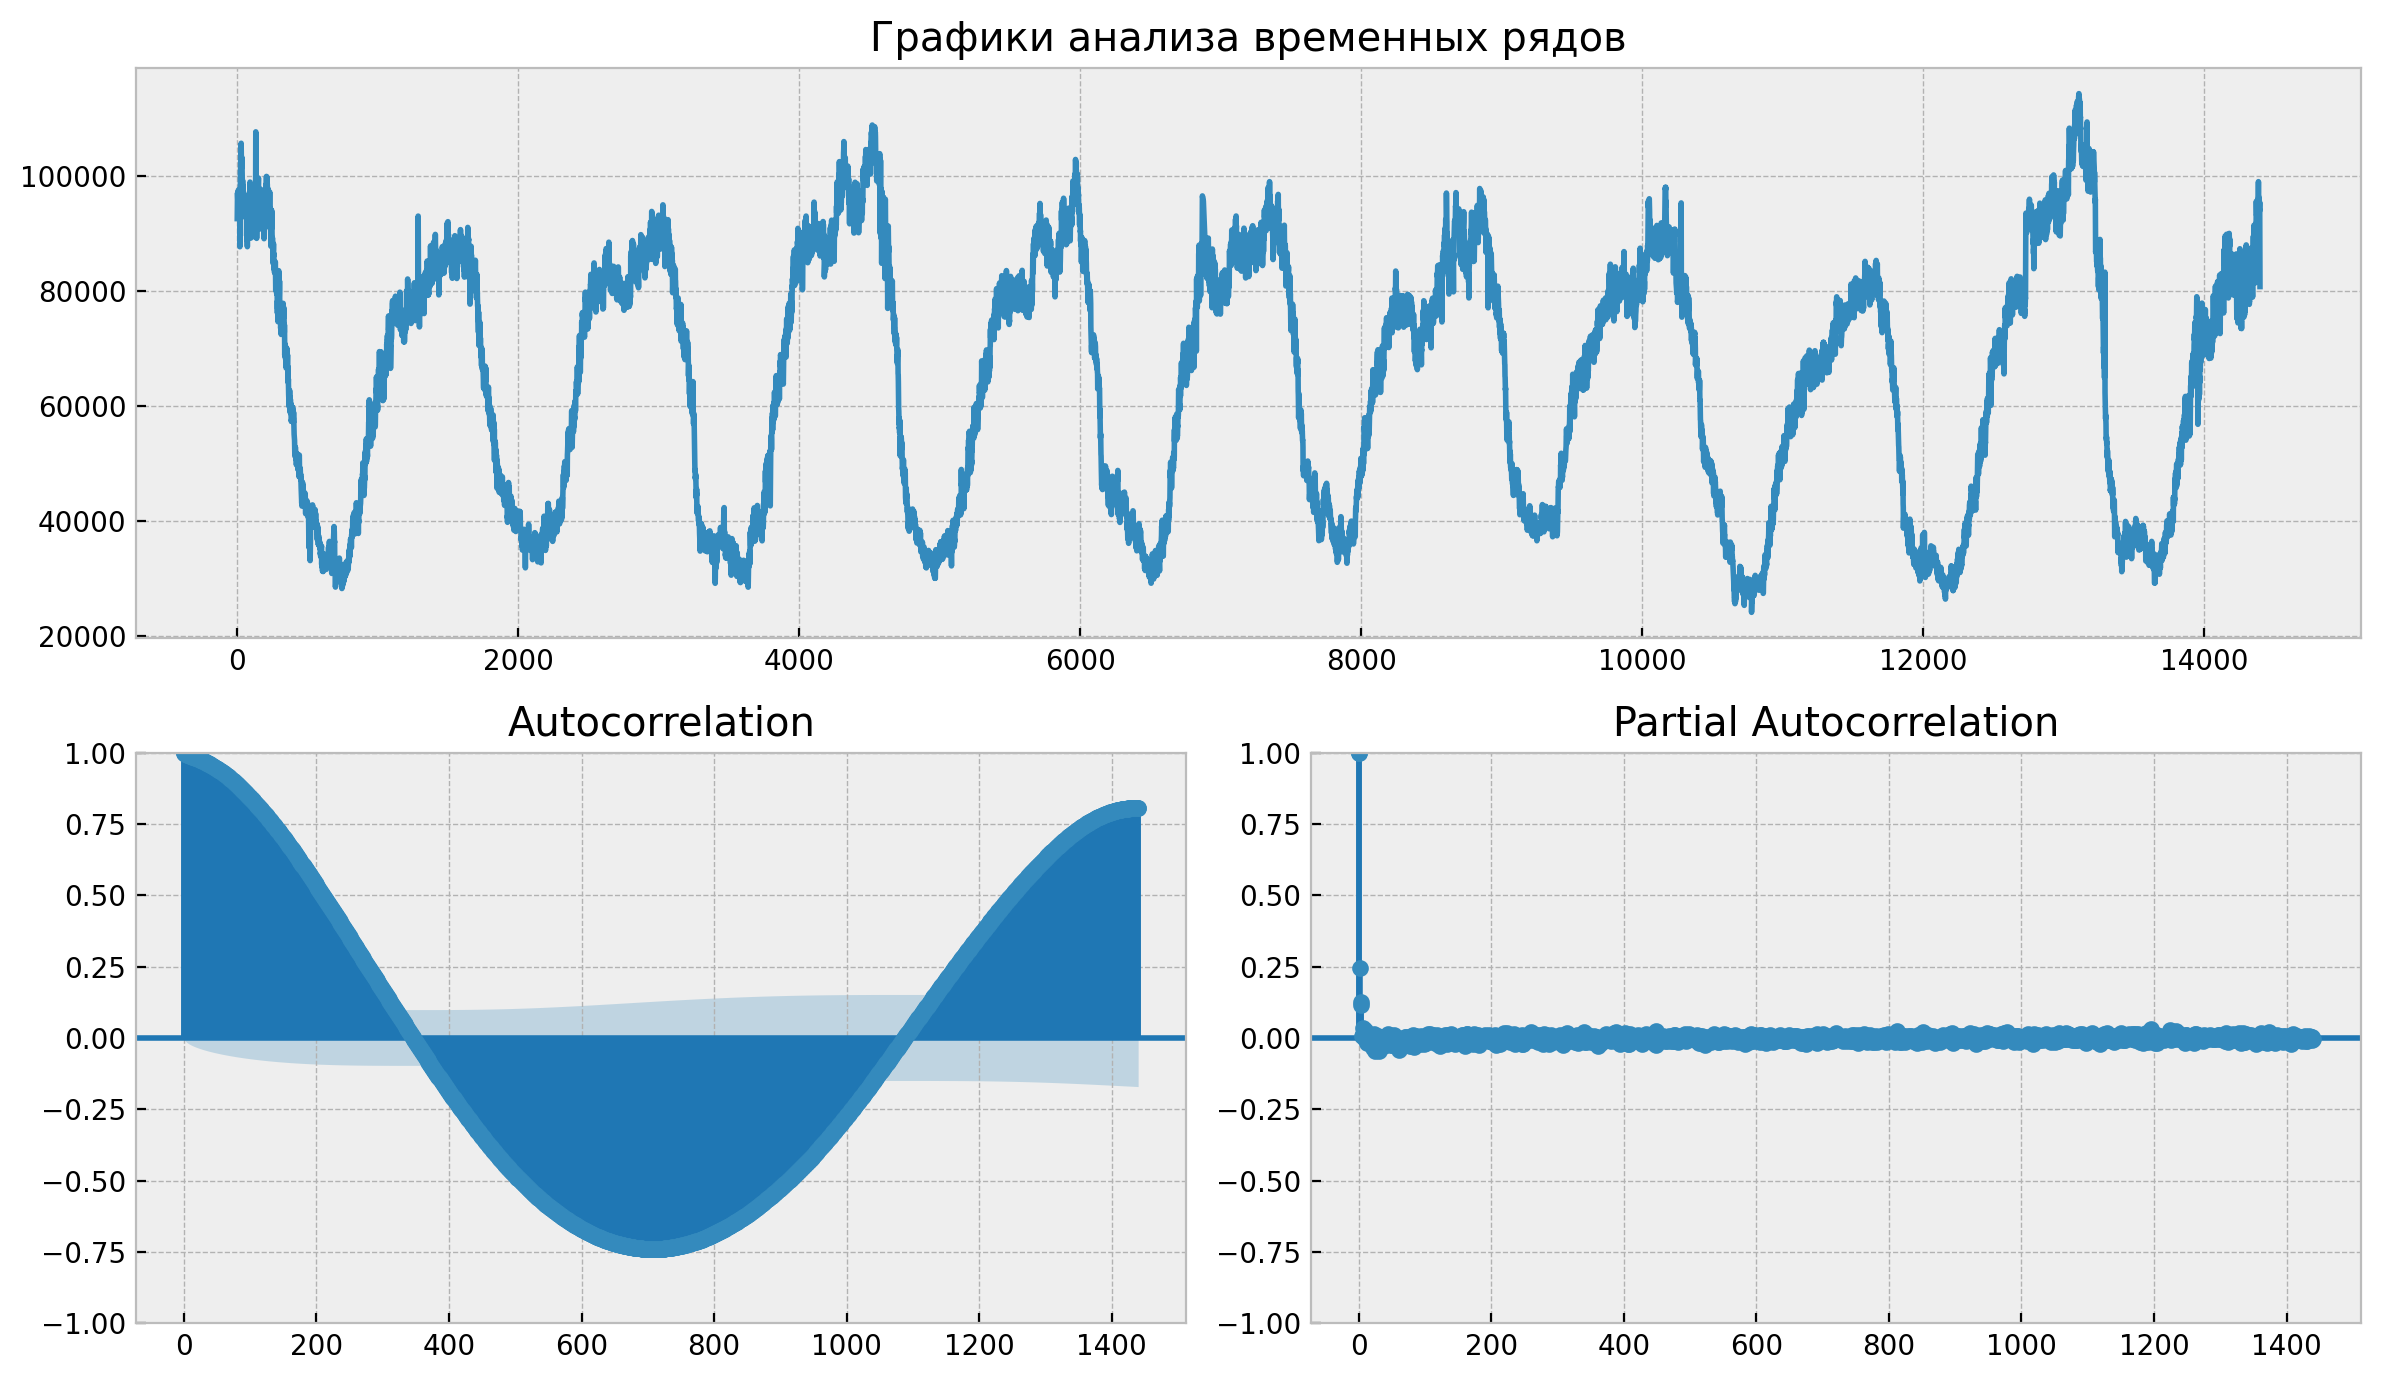

In [ ]:
tsplot(data_filled['y'], lags=1440)

Критерий Дики-Фуллера: p=0.007738


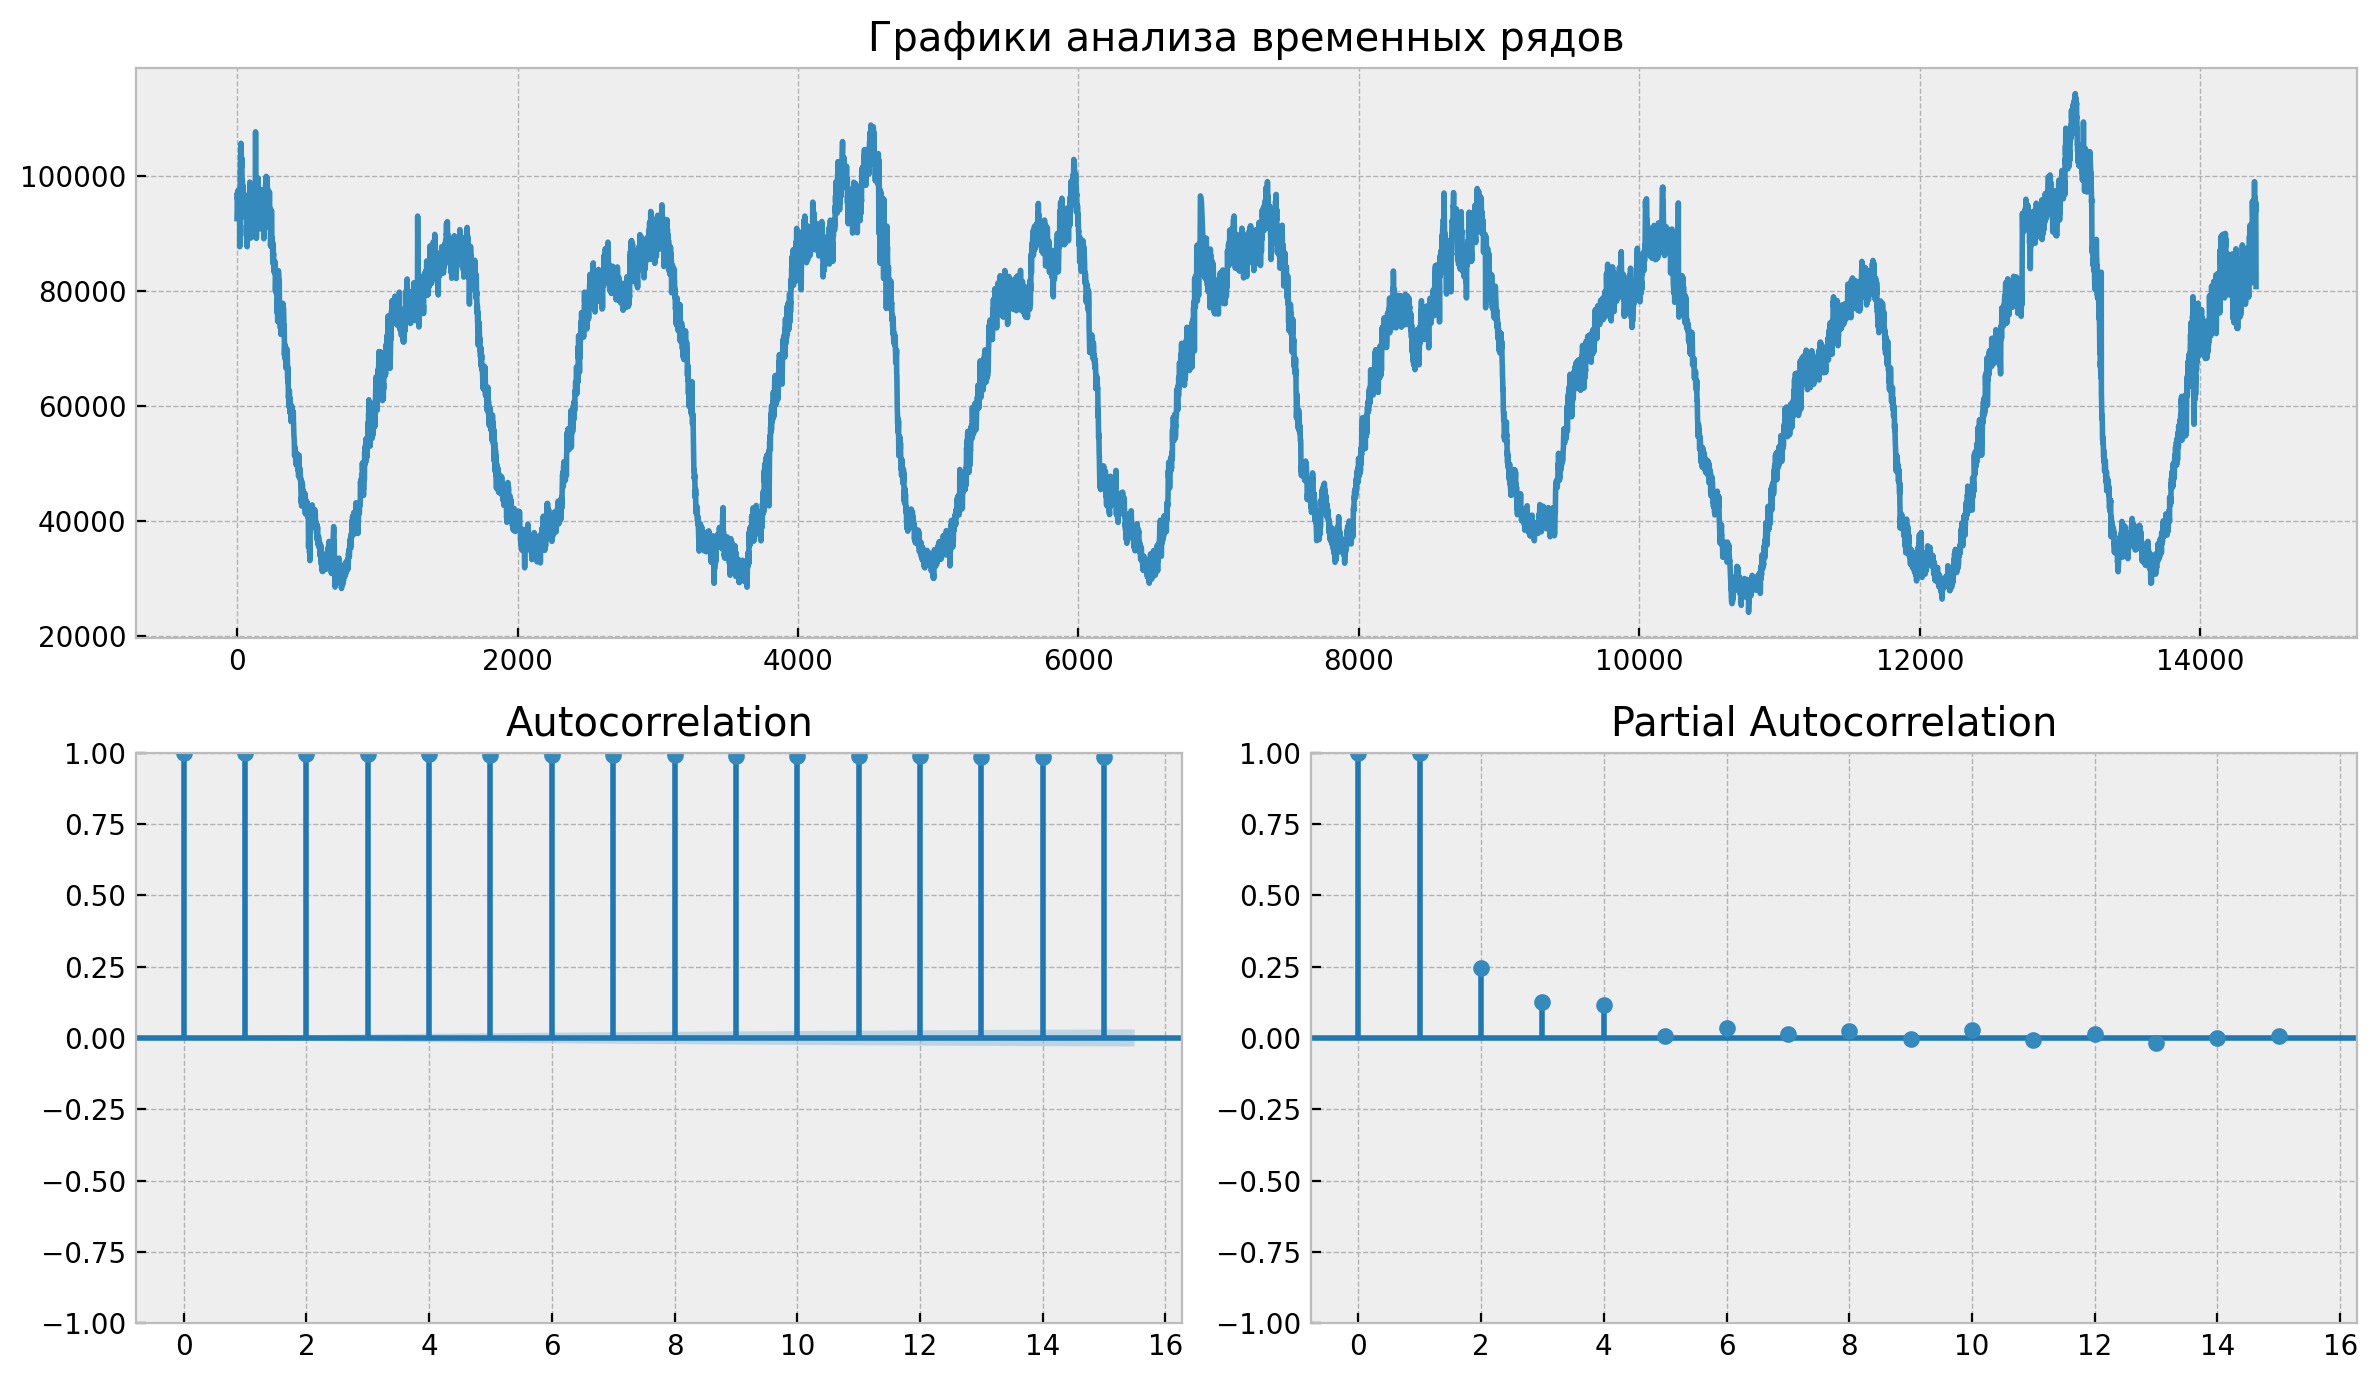

In [ ]:
tsplot(data_filled['y'], lags=15)

 На графике PACF видно что  лаг 1, оказывает самое большое т влияние на текущее значение.

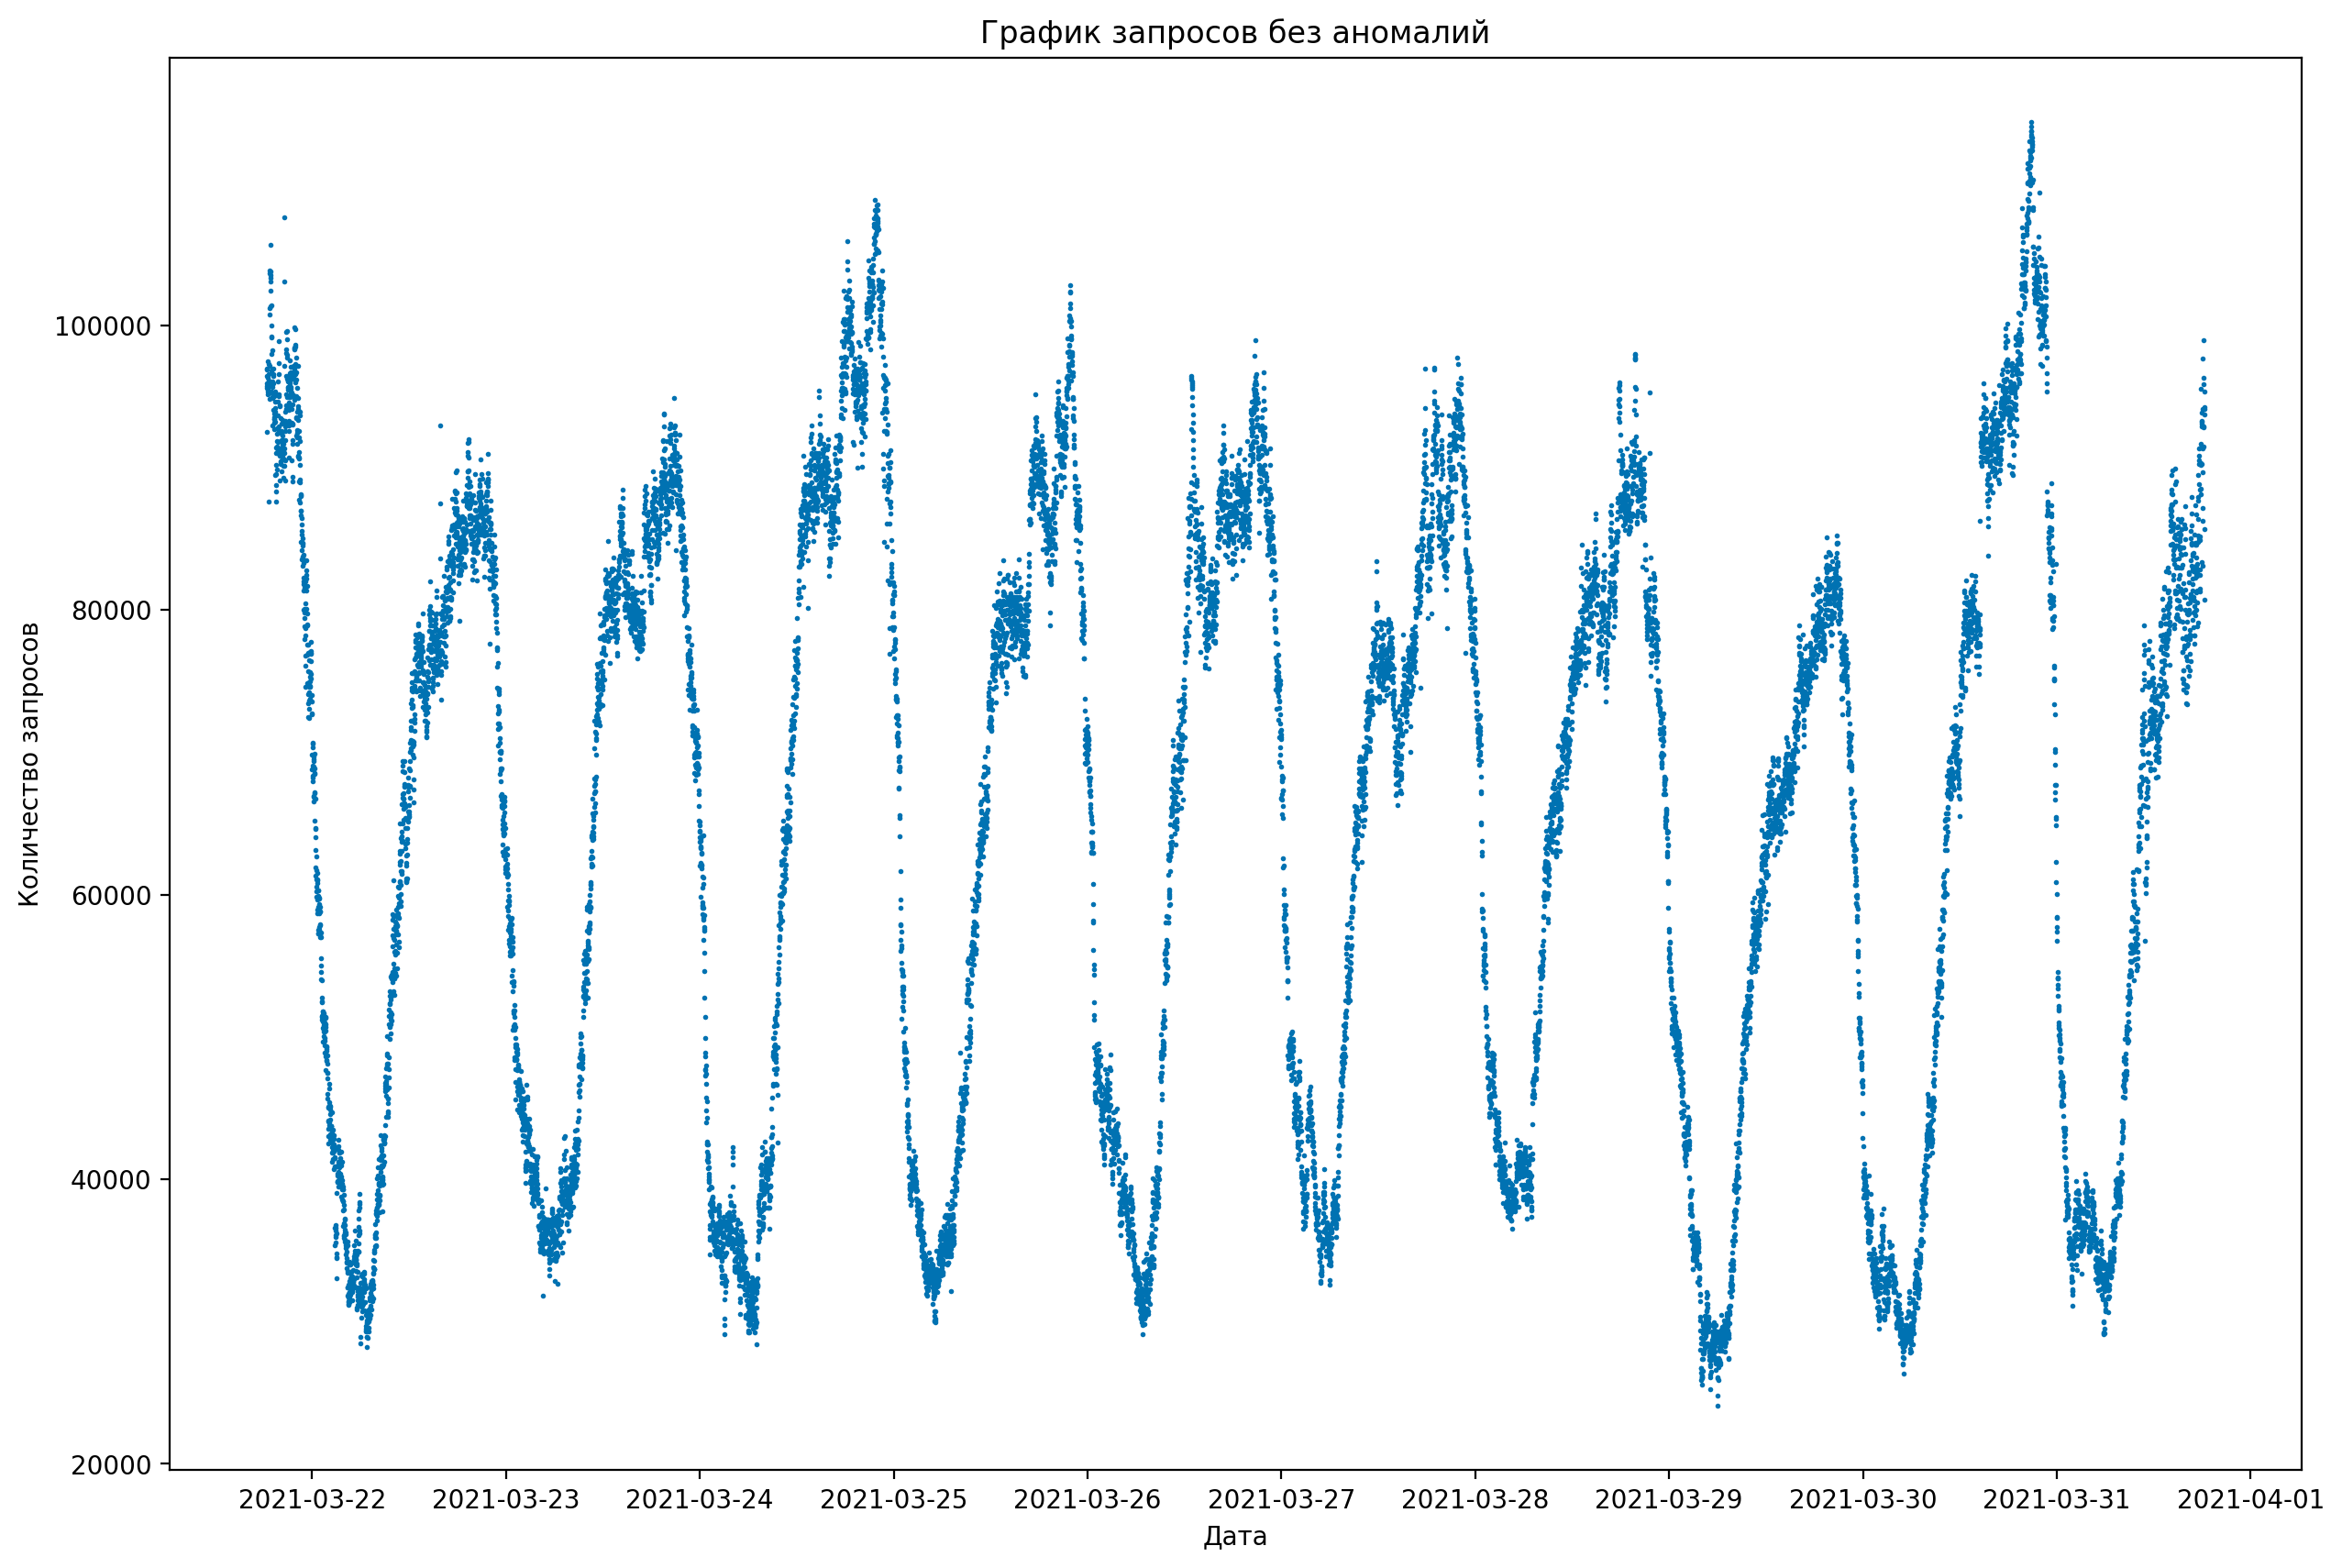

In [ ]:
# визуализируем ряд
plt.figure(figsize=(15, 10))
plt.scatter(pd.to_datetime(data_filled['ds']),
            data_filled['y'],
            s=1,
            c='#0072B2')
plt.xlabel('Дата')
plt.ylabel(r'Количество запросов')
plt.title('График запросов без аномалий')
plt.show()

Добавляем новые признаки

In [ ]:
# Лаги
data_filled['lag_1'] = data_filled['y'].shift(1)
data_filled['lag_2'] = data_filled['y'].shift(2)
data_filled['lag_720'] = data_filled['y'].shift(720)
data_filled['lag_1440'] = data_filled['y'].shift(1440)

# Скользящие статистики для 720 (12 часов)
data_filled["rolling_sum"] = data_filled['y'].rolling(720).sum()
data_filled['rolling_mean_720'] = data_filled['y'].rolling(720).mean()
data_filled['rolling_median_720'] = data_filled['y'].rolling(720).median()
data_filled['rolling_std_720'] = data_filled['y'].rolling(720).std()
data_filled['rolling_min_720'] = data_filled['y'].rolling(720).min()
data_filled['rolling_max_720'] = data_filled['y'].rolling(720).max()

# Скользящие статистики для 1440 (24 часа)
data_filled['rolling_mean_1440'] = data_filled['y'].rolling(1440).mean()
data_filled['rolling_median_1440'] = data_filled['y'].rolling(1440).median()
data_filled['rolling_std_1440'] = data_filled['y'].rolling(1440).std()
data_filled['rolling_min_1440'] = data_filled['y'].rolling(1440).min()
data_filled['rolling_max_1440'] = data_filled['y'].rolling(1440).max()

#Час, день недели, выходные
data_filled['hour'] = data_filled['ds'].dt.hour
data_filled['day_of_week'] = data_filled['ds'].dt.dayofweek
data_filled['is_weekend'] = data_filled['day_of_week'].isin([6, 7]).astype(int)


# Дополнительные признаки: отношения и размах
data_filled['lag_1_ratio'] = data_filled['y'] / (data_filled['lag_1'])
data_filled['lag_2_ratio'] = data_filled['y'] / (data_filled['lag_2'])
data_filled['lag_720_ratio'] = data_filled['y'] / (data_filled['lag_720'])
data_filled['lag_1440_ratio'] = data_filled['y'] / (data_filled['lag_1440'])
data_filled['lag_diff_1'] = data_filled['y'] - data_filled['lag_1']
data_filled['lag_diff_2'] = data_filled['y'] - data_filled['lag_2']
data_filled['rolling_range_720'] = data_filled['rolling_max_720'] - data_filled['rolling_min_720']
data_filled['rolling_range_1440'] = data_filled['rolling_max_1440'] - data_filled['rolling_min_1440']

In [ ]:
# Проверка результата
print(f"Присутствие пропусков? {data_filled.isnull().any().any()}")
print(data_filled.head(10))

Присутствие пропусков? True
                   ds        y    lag_1    lag_2  lag_720  lag_1440  \
0 2021-03-21 18:21:00  92523.0      NaN      NaN      NaN       NaN   
1 2021-03-21 18:22:00  95961.0  92523.0      NaN      NaN       NaN   
2 2021-03-21 18:23:00  96984.0  95961.0  92523.0      NaN       NaN   
3 2021-03-21 18:24:00  96463.0  96984.0  95961.0      NaN       NaN   
4 2021-03-21 18:25:00  95768.0  96463.0  96984.0      NaN       NaN   
5 2021-03-21 18:26:00  96919.0  95768.0  96463.0      NaN       NaN   
6 2021-03-21 18:27:00  95627.0  96919.0  95768.0      NaN       NaN   
7 2021-03-21 18:28:00  95601.0  95627.0  96919.0      NaN       NaN   
8 2021-03-21 18:29:00  97496.0  95601.0  95627.0      NaN       NaN   
9 2021-03-21 18:30:00  95365.0  97496.0  95601.0      NaN       NaN   

   rolling_sum  rolling_mean_720  rolling_median_720  rolling_std_720  ...  \
0          NaN               NaN                 NaN              NaN  ...   
1          NaN               NaN  

In [ ]:
# Признаки, относящиеся к скользящей статистике
rolling_features = ['rolling_mean_720', 'rolling_median_720', 'rolling_std_720', 'rolling_min_720', 'rolling_max_720',
                    'rolling_mean_1440', 'rolling_median_1440', 'rolling_std_1440', 'rolling_min_1440', 'rolling_max_1440']

# Линейная интерполяция для обработки NaN в скользящих статистиках
data_filled[rolling_features] = data_filled[rolling_features].fillna(data_filled[rolling_features].median())

# Замена NaN на 0 только для определенных признаков
fill_zero_features = ['lag_1', 'lag_2', 'lag_720', 'lag_1440', 'lag_1_ratio', 'lag_2_ratio', 'lag_720_ratio',
                      'lag_1440_ratio', 'lag_diff_1', 'lag_diff_2','rolling_range_720', 'rolling_range_1440',
                      'rolling_sum']

data_filled[fill_zero_features] = data_filled[fill_zero_features].fillna(0)

In [ ]:
# Проверка результата
print(f"Остались ли пропуски? {data_filled.isnull().any().any()}")

Остались ли пропуски? False


## Модель LGBMRegressor с RFECV для отбора признаков

In [ ]:
X = data_filled.drop(columns=['ds', 'y'])
y = data_filled['y']

In [ ]:
# Разделение данных на тренировочную часть (без последних двух минут) и тестовую (последнии 2 минуты)
X_train = X.iloc[:-2]
y_train = y.iloc[:-2]
X_test = X.iloc[-2:]
y_test = y.iloc[-2:]

In [ ]:
# Создаем TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Создаем оценщик для MAPE
scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

# Шаг 1: RFECV для отбора признаков
print("Запуск RFECV для отбора признаков...")
model = LGBMRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
)

selector = RFECV(
    estimator=model,
    step=1,
    cv=tscv,
    scoring=scorer,
    verbose=0
)

# Применяем RFECV на обучающих данных
selector.fit(X_train, y_train)

# Выбираем отобранные признаки
selected_features = X_train.columns[selector.support_]
print(f"Отобранные признаки: {list(selected_features)}")

# Отбор признаков на основе RFECV
X_train_selected = X_train[selected_features]

# Шаг 2: Кросс-валидация с выбранными признаками
cv_mape_scores = []

# Массив для хранения важностей признаков
feature_importances = np.zeros(len(selected_features))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_selected)):
    print(f"\nФолд {fold + 1}/5")

    # Данные для текущего фолда
    X_train_fold, X_val_fold = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Создаем и обучаем модель
    model = LGBMRegressor(random_state=42)
    model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold))

    # Предсказания и метрика
    y_val_pred = model.predict(X_val_fold)
    mape = mean_absolute_percentage_error(y_val_fold, y_val_pred)
    cv_mape_scores.append(mape)

    # Суммируем важности признаков
    feature_importances += model.feature_importances_

# Усредняем важности признаков
feature_importances /= tscv.get_n_splits()

# Средний MAPE по всем фолдам
mean_mape = np.mean(cv_mape_scores)
print(f"\nСредний MAPE на кросс-валидации: {mean_mape:.6f}")

# Вывод важности признаков
feature_importances_df = pd.DataFrame({
    "Признак": selected_features,
    "Важность": feature_importances
}).sort_values(by="Важность", ascending=False)

print("\nВажность отобранных признаков:")
print(feature_importances_df)

Запуск RFECV для отбора признаков...
Отобранные признаки: ['lag_1', 'lag_1_ratio', 'lag_diff_1']

Фолд 1/5

Фолд 2/5

Фолд 3/5

Фолд 4/5

Фолд 5/5

Средний MAPE на кросс-валидации: 0.004729

Важность отобранных признаков:
       Признак  Важность
0        lag_1    1449.8
1  lag_1_ratio     929.2
2   lag_diff_1     621.0


Важность отобранных признаков:

 - lag_1  **важность** - 1449.8
 - lag_1_ratio  **важность**   - 929.2
 - lag_diff_1 **важность**   - 621.0

Важность признаков подтверждает наше предположение после анализа условной автокорреляции, что 1 лаг является самым важным из всех созданных признаков

In [ ]:
selected_features

Index(['lag_1', 'lag_1_ratio', 'lag_diff_1'], dtype='object')

In [ ]:
X_new = X[['lag_1', 'lag_1_ratio', 'lag_diff_1']]

## Модель Prophet с добавлением регрессоров

In [ ]:
data = data_filled[['ds', 'y', 'lag_1', 'lag_1_ratio', 'lag_diff_1']]
data

,ds,y,lag_1,lag_1_ratio,lag_diff_1
0,2021-03-21 18:21:00,92523.0,0.0,0.000000,0.0
1,2021-03-21 18:22:00,95961.0,92523.0,1.037158,3438.0
2,2021-03-21 18:23:00,96984.0,95961.0,1.010661,1023.0
3,2021-03-21 18:24:00,96463.0,96984.0,0.994628,-521.0
4,2021-03-21 18:25:00,95768.0,96463.0,0.992795,-695.0
...,...,...,...,...,...
14394,2021-03-31 18:15:00,93750.0,94284.0,0.994336,-534.0
14395,2021-03-31 18:16:00,94111.0,93750.0,1.003851,361.0
14396,2021-03-31 18:17:00,95376.0,94111.0,1.013442,1265.0
14397,2021-03-31 18:18:00,85692.0,95376.0,0.898465,-9684.0


In [ ]:
train_data = data.iloc[:-1]
last_minute = data.iloc[-1:]

In [ ]:
train_data

,ds,y,lag_1,lag_1_ratio,lag_diff_1
0,2021-03-21 18:21:00,92523.0,0.0,0.000000,0.0
1,2021-03-21 18:22:00,95961.0,92523.0,1.037158,3438.0
2,2021-03-21 18:23:00,96984.0,95961.0,1.010661,1023.0
3,2021-03-21 18:24:00,96463.0,96984.0,0.994628,-521.0
4,2021-03-21 18:25:00,95768.0,96463.0,0.992795,-695.0
...,...,...,...,...,...
14393,2021-03-31 18:14:00,94284.0,92882.0,1.015094,1402.0
14394,2021-03-31 18:15:00,93750.0,94284.0,0.994336,-534.0
14395,2021-03-31 18:16:00,94111.0,93750.0,1.003851,361.0
14396,2021-03-31 18:17:00,95376.0,94111.0,1.013442,1265.0


In [ ]:
last_minute

,ds,y,lag_1,lag_1_ratio,lag_diff_1
14398,2021-03-31 18:19:00,80706.0,85692.0,0.941815,-4986.0


In [ ]:
# Инициализация модели Prophet
prophet_model = Prophet(changepoint_prior_scale=0.041,  # значение по умолчанию 0.05
                        daily_seasonality=False,
                        weekly_seasonality=True)

# Добавление минутной сезонности
prophet_model.add_seasonality(name='minutely', period=1, fourier_order=5)

# Добавление регрессоров
regressors = ['lag_1', 'lag_1_ratio', 'lag_diff_1']

for regressor in regressors:
    prophet_model.add_regressor(regressor)

# Обучение модели
prophet_model.fit(train_data)

# Создание будущего датафрейма
future = prophet_model.make_future_dataframe(periods=1, freq='T', include_history=False)

# Обязательно добавляем регрессоры в future
for regressor in regressors:
    future[regressor] = data[regressor].iloc[-1]  # Подставляем последнее значение регрессоров

# Прогнозирование
y_prophet_forecast = prophet_model.predict(future)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/ep_n3ydp.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/lfrvyysz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=72570', 'data', 'file=/tmp/tmpg8d4wmti/ep_n3ydp.json', 'init=/tmp/tmpg8d4wmti/lfrvyysz.json', 'output', 'file=/tmp/tmpg8d4wmti/prophet_model99fxl8x3/prophet_model-20250226190110.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:01:10 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:01:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
y_prophet_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,minutely,minutely_lower,minutely_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-03-31 18:19:00,64927.541281,79369.361063,80752.030594,64927.541281,64927.541281,15168.45591,15168.45591,15168.45591,14729.455134,...,419.451064,419.451064,419.451064,19.549712,19.549712,19.549712,0.0,0.0,0.0,80095.997191


In [ ]:
#Формула расчета MSE	MAE	MAPE
def add_method_comparison(method: str, y_true, y_forecast, compare_table=None) -> pd.DataFrame:
    result_row = {
        'method': method,
        "MSE": mean_squared_error(y_true=y_true, y_pred=y_forecast),
        "MAE": mean_absolute_error(y_true=y_true, y_pred=y_forecast),
        "MAPE": mean_absolute_percentage_error(y_true=y_true, y_pred=y_forecast)
    }

    if compare_table is None:
        compare_table = pd.DataFrame([result_row])
    else:
        if method in list(compare_table['method']):
            compare_table = compare_table[compare_table['method'] != method]

        compare_table = pd.concat([compare_table, pd.DataFrame([result_row])])
        compare_table.index = np.arange(len(compare_table))
    return compare_table

In [ ]:
compare_table = add_method_comparison('Prophet', last_minute['y'], y_prophet_forecast['yhat'])
compare_table

,method,MSE,MAE,MAPE
0,Prophet,372103.427563,610.002809,0.007558


In [ ]:
prophet_train_df = data.iloc[-1440:]

In [ ]:
prophet_train_df

,ds,y,lag_1,lag_1_ratio,lag_diff_1
12959,2021-03-30 18:20:00,95796.0,97124.0,0.986327,-1328.0
12960,2021-03-30 18:21:00,95502.0,95796.0,0.996931,-294.0
12961,2021-03-30 18:22:00,95295.0,95502.0,0.997833,-207.0
12962,2021-03-30 18:23:00,94043.0,95295.0,0.986862,-1252.0
12963,2021-03-30 18:24:00,93755.0,94043.0,0.996938,-288.0
...,...,...,...,...,...
14394,2021-03-31 18:15:00,93750.0,94284.0,0.994336,-534.0
14395,2021-03-31 18:16:00,94111.0,93750.0,1.003851,361.0
14396,2021-03-31 18:17:00,95376.0,94111.0,1.013442,1265.0
14397,2021-03-31 18:18:00,85692.0,95376.0,0.898465,-9684.0


### Модель Prophet с добавлением регрессоров и кросс-валидацией

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

# Добавление модели Prophet
m = Prophet(changepoint_prior_scale=0.041,
            daily_seasonality=False,
            weekly_seasonality=True)

# Добавление минутной сезонности
m.add_seasonality(name='minutely', period=1, fourier_order=5)

# Добавление регрессоров
regressors = ['lag_1', 'lag_1_ratio', 'lag_diff_1']
for regressor in regressors:
    m.add_regressor(regressor)

# Обучение модели
m.fit(train_data)

# Перекрёстная проверка
df_cv = cross_validation(m, initial='12950 minutes', period='1 minutes', horizon='1 minutes')

# Метрики
df_p = performance_metrics(df_cv)

# Вывод результатов
df_p.head(5)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/kl9fs_fn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/zuw48jgg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=55790', 'data', 'file=/tmp/tmpg8d4wmti/kl9fs_fn.json', 'init=/tmp/tmpg8d4wmti/zuw48jgg.json', 'output', 'file=/tmp/tmpg8d4wmti/prophet_modelgqtd75jv/prophet_model-20250226192902.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:29:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:29:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  0%|          | 0/1447 [00:00<?, ?it/s]

Выходные данные были обрезаны до нескольких последних строк (5000).
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=74281', 'data', 'file=/tmp/tmpg8d4wmti/jwlths6h.json', 'init=/tmp/tmpg8d4wmti/a85tcki7.json', 'output', 'file=/tmp/tmpg8d4wmti/prophet_model4hpf4s0i/prophet_model-20250226204046.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:40:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:40:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/awmfzin1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8d4wmti/a2xzrlsj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14753', 'data', 'file=/tmp/tmpg8d4wmti/awmfzin1

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,0 days 00:01:00,192511.982805,438.761875,320.728761,0.006232,0.003546,0.006232,0.909468


## Модель LGBMRegressor и подбор гиперпараметров с OPTUNA

### Прогноз на следующую минуту и расчет MAPE

In [ ]:
# Отбираем данные только с важными признаками
X_train_important = X_new.iloc[:-1]
y_train_important = y.iloc[:-1]
X_test_important = X_new.iloc[-1:]
y_test_important = y.iloc[-1:]

# Функция для оптимизации
def objective(trial):
    # Подбор гиперпараметров
    n_estimators = trial.suggest_int('n_estimators', 100, 600, step=50)
    num_leaves = trial.suggest_int('num_leaves', 20, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.05, step=0.01)
    reg_alpha = trial.suggest_float('reg_alpha', 0.0, 10.0, step=0.5)
    reg_lambda = trial.suggest_float('reg_lambda', 0.0, 10.0, step=0.5)
    subsample = trial.suggest_float('subsample', 0.7, 1.0, step=0.1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.7, 1.0, step=0.1)

    # Кросс-валидация с временными рядами
    tscv = TimeSeriesSplit(n_splits=5)
    cv_mape_scores = []

    for train_index, val_index in tscv.split(X_train_important):
        X_train_fold, X_val_fold = X_train_important.iloc[train_index], X_train_important.iloc[val_index]
        y_train_fold, y_val_fold = y_train_important.iloc[train_index], y_train_important.iloc[val_index]

        # Обучение модели
        model = LGBMRegressor(
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            learning_rate=learning_rate,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42,
            verbose=-1
        )
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)])

        # Оценка на валидационной выборке
        y_val_pred = model.predict(X_val_fold)
        cv_mape_scores.append(mean_absolute_percentage_error(y_val_fold, y_val_pred))

    # Средний MAPE на кросс-валидации
    mape_validation = np.mean(cv_mape_scores)

    # Предсказание на тестовой выборке
    model.fit(X_train_important, y_train_important)
    y_test_pred_important = model.predict(X_test_important)
    mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)

    # Взвешенная метрика
    return 0.5 * mape_validation + 0.5 * mape_test

# Оптимизация гиперпараметров с Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Лучшие гиперпараметры
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

[I 2025-03-01 18:49:51,586] A new study created in memory with name: no-name-9768d302-c4c4-42af-b401-e2d70381bbe5
[I 2025-03-01 18:49:58,748] Trial 0 finished with value: 0.0123693007280487 and parameters: {'n_estimators': 500, 'num_leaves': 20, 'learning_rate': 0.05, 'reg_alpha': 2.5, 'reg_lambda': 6.0, 'subsample': 0.7999999999999999, 'colsample_bytree': 0.7999999999999999}. Best is trial 0 with value: 0.0123693007280487.
[I 2025-03-01 18:50:03,248] Trial 1 finished with value: 0.004287041128867701 and parameters: {'n_estimators': 500, 'num_leaves': 30, 'learning_rate': 0.03, 'reg_alpha': 7.5, 'reg_lambda': 10.0, 'subsample': 0.8999999999999999, 'colsample_bytree': 0.8999999999999999}. Best is trial 1 with value: 0.004287041128867701.
[I 2025-03-01 18:50:06,170] Trial 2 finished with value: 0.007792327988875538 and parameters: {'n_estimators': 350, 'num_leaves': 30, 'learning_rate': 0.01, 'reg_alpha': 0.5, 'reg_lambda': 6.0, 'subsample': 1.0, 'colsample_bytree': 1.0}. Best is trial 1

Лучшие гиперпараметры: {'n_estimators': 600, 'num_leaves': 90, 'learning_rate': 0.03, 'reg_alpha': 3.5, 'reg_lambda': 1.5, 'subsample': 1.0, 'colsample_bytree': 0.8999999999999999}


In [ ]:
# Оценка модели с лучшими гиперпараметрами
model_lgb = LGBMRegressor(
    n_estimators=best_params['n_estimators'],
    num_leaves=best_params['num_leaves'],
    learning_rate=best_params['learning_rate'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    random_seed=42,
    verbose=-1
)
model_lgb.fit(X_train_important, y_train_important)

# Средний MAPE на кросс-валидации
y_train_pred = model_lgb.predict(X_train_important)
mape_cv = mean_absolute_percentage_error(y_train_important, y_train_pred)
print("Средний MAPE на кросс-валидации:", mape_cv)

# MAPE на последней минуте
y_test_pred_important = model_lgb.predict(X_test_important)
mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)
print("MAPE на последней минуте с оптимизированными гиперпараметрами:", mape_test)

Средний MAPE на кросс-валидации: 0.0016723254921838775
MAPE на последней минуте с оптимизированными гиперпараметрами: 0.0002972727211341366


## Модель CatBoostRegressor и подбор гиперпараметров с OPTUNA

### Прогноз на следующую минуту и расчет MAPE

In [ ]:

# Отбираем данные только с важными признаками
X_train_important = X_new.iloc[:-1]
y_train_important = y.iloc[:-1]
X_test_important = X_new.iloc[-1:]
y_test_important = y.iloc[-1:]


# Функция для оптимизации
def objective(trial):
    # Подбор гиперпараметров
    iterations = trial.suggest_int('iterations', 100, 600, step=50)
    depth = trial.suggest_int('depth', 3, 6, step=1)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.05, step=0.01)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 5, 20, step=1)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.5, 1.0, step=0.1)
    subsample = trial.suggest_float('subsample', 0.7, 1.0, step=0.1)


    # Кросс-валидация с временными рядами
    tscv = TimeSeriesSplit(n_splits=5)
    cv_mape_scores = []

    for train_index, val_index in tscv.split(X_train_important):
        X_train_fold, X_val_fold = X_train_important.iloc[train_index], X_train_important.iloc[val_index]
        y_train_fold, y_val_fold = y_train_important.iloc[train_index], y_train_important.iloc[val_index]

        # Обучение модели
        model = CatBoostRegressor(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=l2_leaf_reg,
            bagging_temperature=bagging_temperature,
            random_seed=42,
            verbose=0
        )
        model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), verbose=0)

        # Оценка на валидационной выборке
        y_val_pred = model.predict(X_val_fold)
        cv_mape_scores.append(mean_absolute_percentage_error(y_val_fold, y_val_pred))

    # Средний MAPE на кросс-валидации
    mape_validation = np.mean(cv_mape_scores)

    # Предсказание на тестовой выборке
    model.fit(X_train_important, y_train_important, verbose=0)
    y_test_pred_important = model.predict(X_test_important)
    mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)

    # Взвешенная метрика
    return 0.5 * mape_validation + 0.5 * mape_test

# Оптимизация гиперпараметров с Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Лучшие гиперпараметры
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

[I 2025-02-27 18:33:16,281] A new study created in memory with name: no-name-8b05e3d8-0b71-404f-9388-e3af1cacbd07
[I 2025-02-27 18:33:17,978] Trial 0 finished with value: 0.03008403168533615 and parameters: {'iterations': 200, 'depth': 3, 'learning_rate': 0.02, 'l2_leaf_reg': 13.0, 'bagging_temperature': 0.9, 'subsample': 0.7999999999999999}. Best is trial 0 with value: 0.03008403168533615.
[I 2025-02-27 18:33:30,521] Trial 1 finished with value: 0.006490826889382384 and parameters: {'iterations': 600, 'depth': 5, 'learning_rate': 0.02, 'l2_leaf_reg': 16.0, 'bagging_temperature': 0.6, 'subsample': 0.8999999999999999}. Best is trial 1 with value: 0.006490826889382384.
[I 2025-02-27 18:33:32,834] Trial 2 finished with value: 0.012211992130429925 and parameters: {'iterations': 250, 'depth': 4, 'learning_rate': 0.02, 'l2_leaf_reg': 13.0, 'bagging_temperature': 0.9, 'subsample': 0.7999999999999999}. Best is trial 1 with value: 0.006490826889382384.
[I 2025-02-27 18:33:38,067] Trial 3 finish

Лучшие гиперпараметры: {'iterations': 350, 'depth': 6, 'learning_rate': 0.04, 'l2_leaf_reg': 14.0, 'bagging_temperature': 0.5, 'subsample': 0.7999999999999999}


In [ ]:
# Оценка модели с лучшими гиперпараметрами
model = CatBoostRegressor(
    iterations=best_params['iterations'],
    depth=best_params['depth'],
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    bagging_temperature=best_params['bagging_temperature'],
    random_seed=42,
    early_stopping_rounds=30,
    verbose=0
)
model.fit(X_train_important, y_train_important, verbose=0)

# Средний MAPE на кросс-валидации
y_train_pred = model.predict(X_train_important)
mape_cv = mean_absolute_percentage_error(y_train_important, y_train_pred)
print("Средний MAPE на кросс-валидации:", mape_cv)

# MAPE на последней минуте
y_test_pred_important = model.predict(X_test_important)
mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)
print("MAPE на последней минуте с оптимизированными гиперпараметрами:", mape_test)


Средний MAPE на кросс-валидации: 0.004219144324388827
MAPE на последней минуте с оптимизированными гиперпараметрами: 0.0002347109810541267


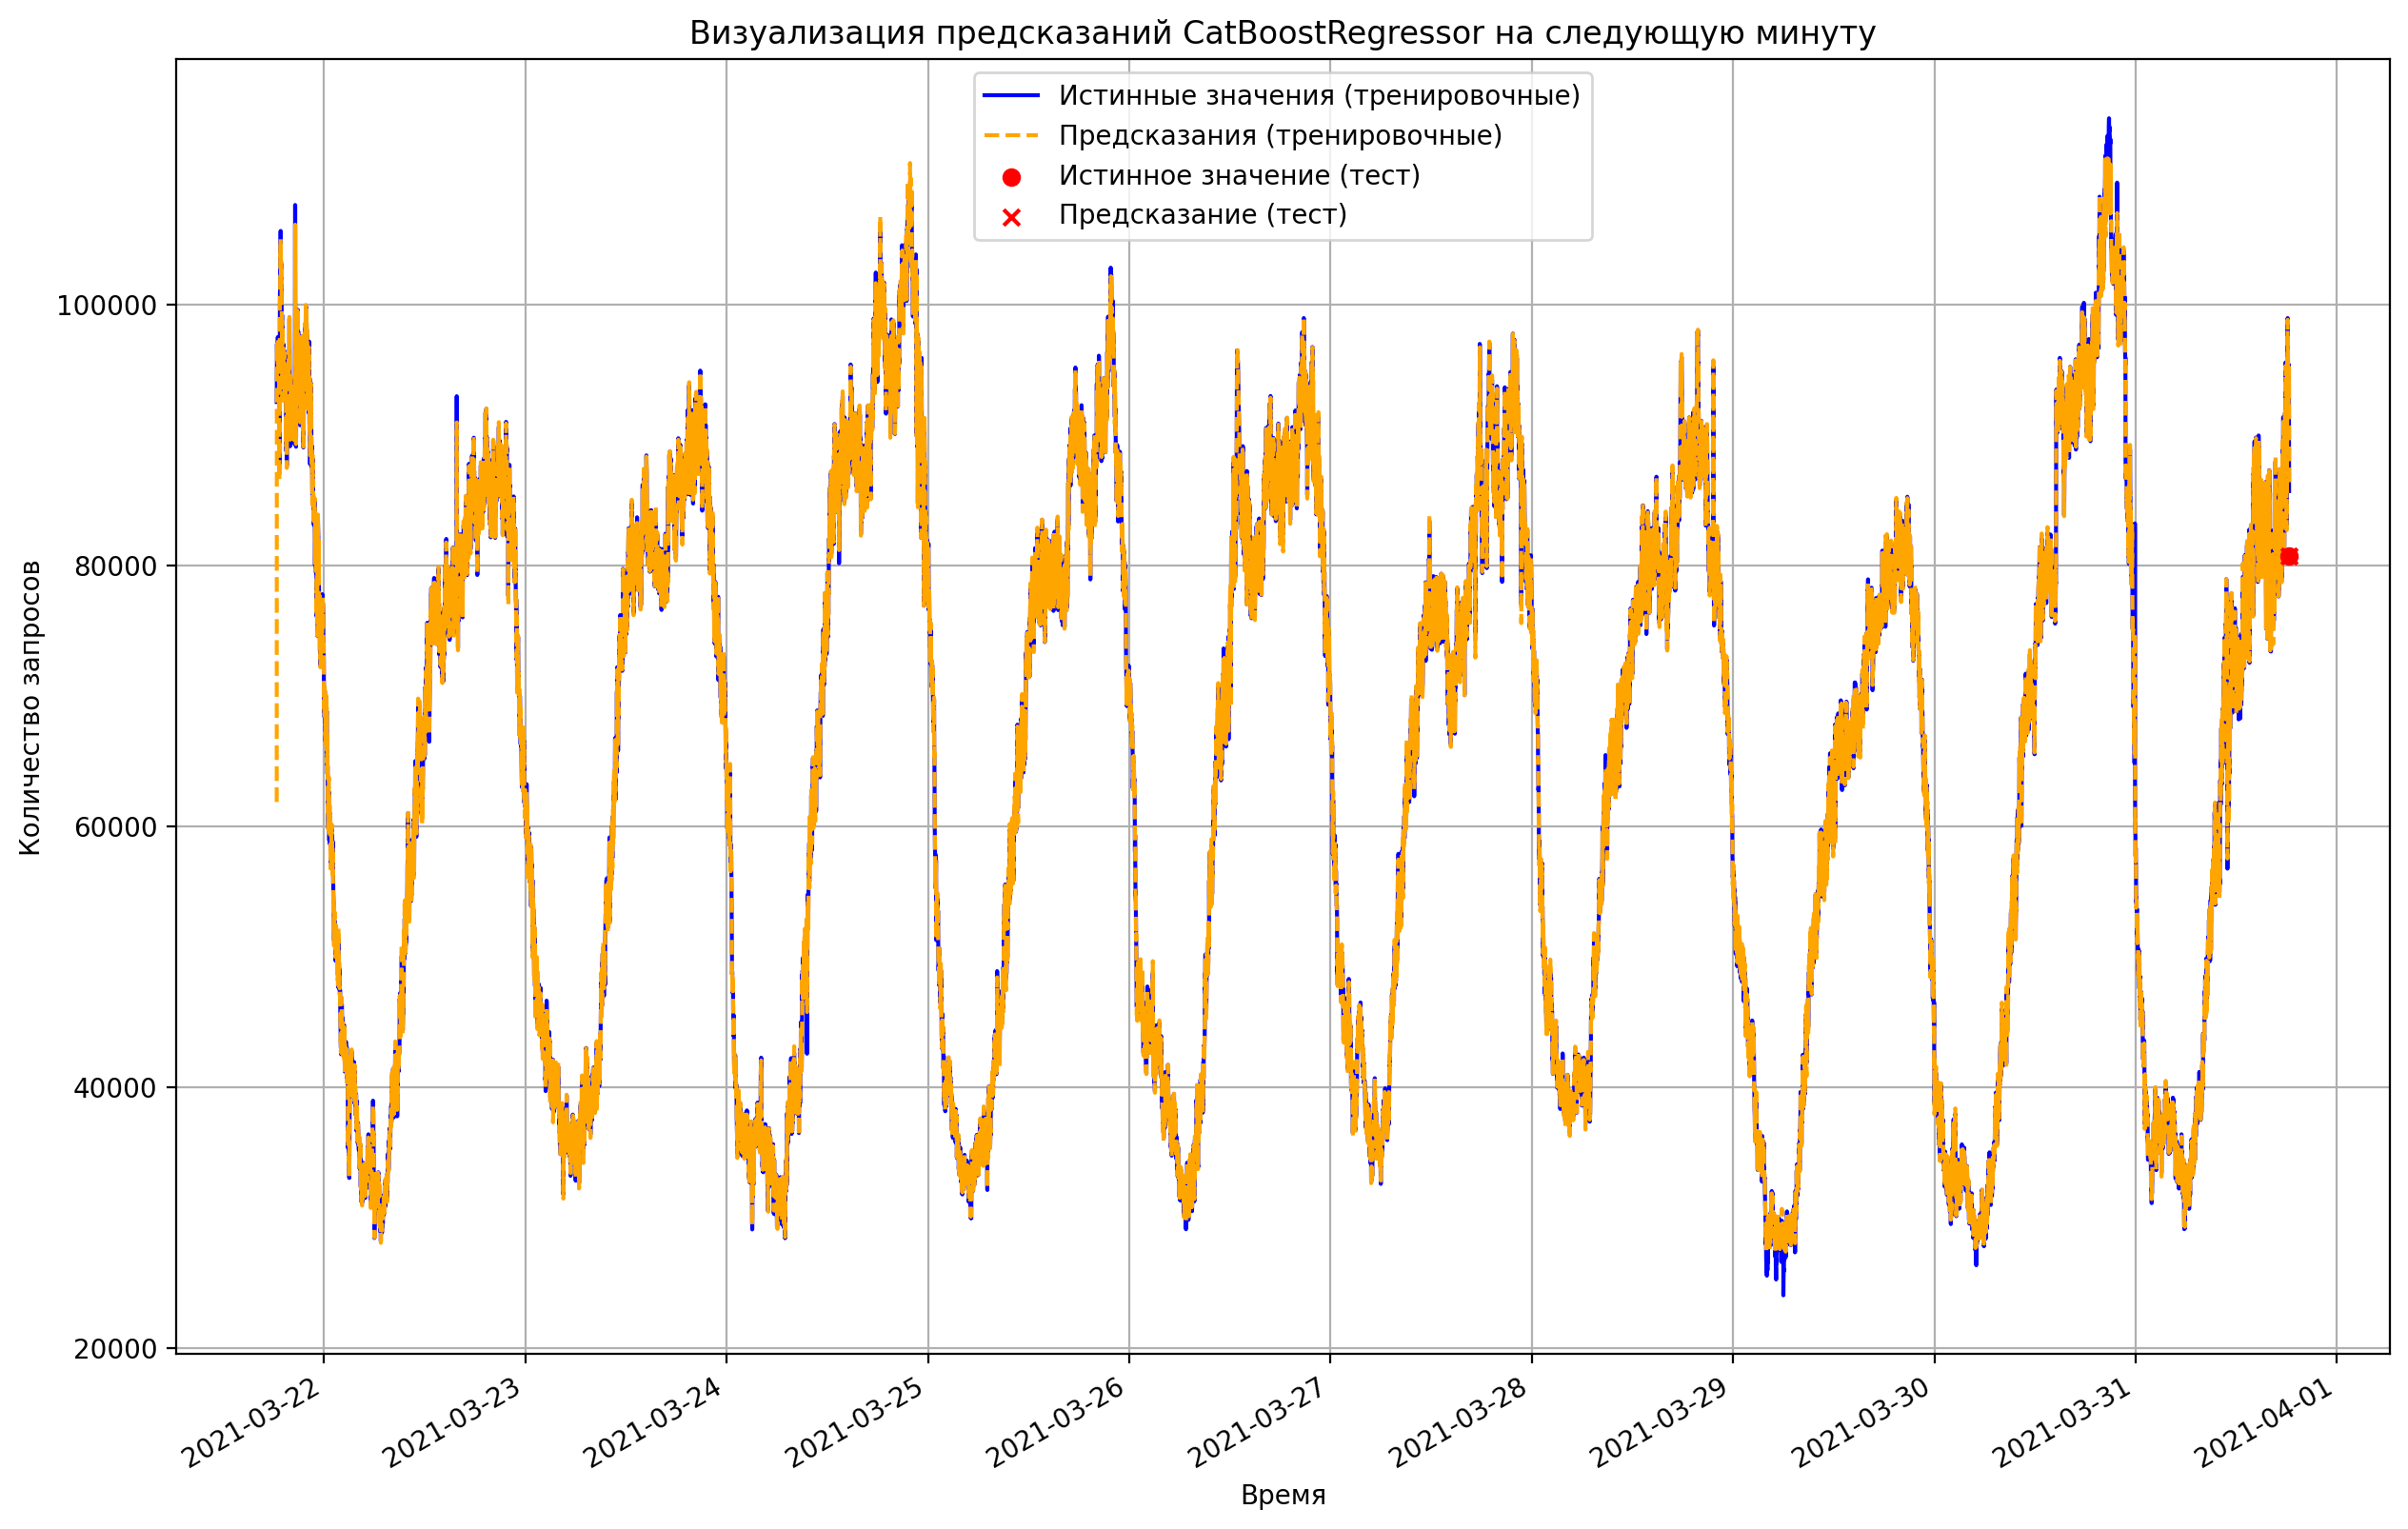

In [ ]:
plt.figure(figsize=(15, 10))

train_time = data_filled['ds'].iloc[:-1]

y_train_pred_series = pd.Series(y_train_pred, index=train_time)

plt.plot(train_time, y_train_important.values, label='Истинные значения (тренировочные)', color='blue')
plt.plot(train_time, y_train_pred_series.values, label='Предсказания (тренировочные)', color='orange', linestyle='--')


test_time = data_filled['ds'].iloc[-1]
y_test_pred_series = pd.Series(y_test_pred_important, index=[test_time])
plt.scatter(test_time, y_test_important.values, color='red', label='Истинное значение (тест)', zorder=5)
plt.scatter(test_time, y_test_pred_series.values, color='red', marker='x', label='Предсказание (тест)', zorder=5)

plt.gcf().autofmt_xdate()

plt.title("Визуализация предсказаний CatBoostRegressor на следующую минуту")
plt.xlabel("Время")
plt.ylabel("Количество запросов")
plt.legend()
plt.grid(True)

plt.show()

### Модель прогноза на следующий час и расчет MAPE

Лучшее качество прогноза на следующую минуту по метрики MAPE у модели CatBoostRegressor. Для прогноза на следующий час и сутки применим модель CatBoostRegressor

In [ ]:
# Отбираем данные только с важными признаками
X_train_important = X_new.iloc[:-60]
y_train_important = y.iloc[:-60]
X_test_important = X_new.iloc[-60:]
y_test_important = y.iloc[-60:]


# Функция для оптимизации
def objective(trial):
    # Подбор гиперпараметров
    iterations = trial.suggest_int('iterations', 100, 1300, step=50)
    depth = trial.suggest_int('depth', 3, 12, step=1)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 10, step=1)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0, step=0.1)

    # Кросс-валидация с временными рядами
    tscv = TimeSeriesSplit(n_splits=5)
    cv_mape_scores = []

    for train_index, val_index in tscv.split(X_train_important):
        X_train_fold, X_val_fold = X_train_important.iloc[train_index], X_train_important.iloc[val_index]
        y_train_fold, y_val_fold = y_train_important.iloc[train_index], y_train_important.iloc[val_index]

        # Обучение модели
        model = CatBoostRegressor(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=l2_leaf_reg,
            bagging_temperature=bagging_temperature,
            random_seed=42,
            verbose=0
        )
        model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), verbose=0)

        # Оценка на валидационной выборке
        y_val_pred = model.predict(X_val_fold)
        cv_mape_scores.append(mean_absolute_percentage_error(y_val_fold, y_val_pred))

    # Средний MAPE на кросс-валидации
    mape_validation = np.mean(cv_mape_scores)

    # Предсказание на тестовой выборке
    model.fit(X_train_important, y_train_important, verbose=0)
    y_test_pred_important = model.predict(X_test_important)
    mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)

    # Взвешенная метрика
    return 0.8 * mape_validation + 0.2 * mape_test

# Оптимизация гиперпараметров с Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Лучшие гиперпараметры
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

[I 2025-02-27 18:47:58,155] A new study created in memory with name: no-name-a738010a-ea69-462f-9598-8b3458219c1c
[I 2025-02-27 18:48:09,111] Trial 0 finished with value: 0.004340788360894368 and parameters: {'iterations': 1050, 'depth': 4, 'learning_rate': 0.04, 'l2_leaf_reg': 10.0, 'bagging_temperature': 0.0}. Best is trial 0 with value: 0.004340788360894368.
[I 2025-02-27 18:49:47,824] Trial 1 finished with value: 0.0030675262130240924 and parameters: {'iterations': 1250, 'depth': 10, 'learning_rate': 0.05, 'l2_leaf_reg': 6.0, 'bagging_temperature': 0.7000000000000001}. Best is trial 1 with value: 0.0030675262130240924.
[I 2025-02-27 18:50:03,810] Trial 2 finished with value: 0.004631294765231079 and parameters: {'iterations': 450, 'depth': 7, 'learning_rate': 0.02, 'l2_leaf_reg': 6.0, 'bagging_temperature': 0.7000000000000001}. Best is trial 1 with value: 0.0030675262130240924.
[I 2025-02-27 18:50:18,444] Trial 3 finished with value: 0.0037796541939457157 and parameters: {'iteratio

Лучшие гиперпараметры: {'iterations': 1150, 'depth': 8, 'learning_rate': 0.09999999999999999, 'l2_leaf_reg': 1.0, 'bagging_temperature': 0.0}


In [ ]:
# Оценка модели с лучшими гиперпараметрами
model = CatBoostRegressor(
    iterations=best_params['iterations'],
    depth=best_params['depth'],
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    bagging_temperature=best_params['bagging_temperature'],
    random_seed=42,
    early_stopping_rounds=100,
    verbose=0
)
model.fit(X_train_important, y_train_important, verbose=0)

# Средний MAPE на кросс-валидации
y_train_pred = model.predict(X_train_important)
mape_cv = mean_absolute_percentage_error(y_train_important, y_train_pred)
print("Средний MAPE на кросс-валидации:", mape_cv)

# MAPE на последней минуте
y_test_pred_important = model.predict(X_test_important)
mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)
print("MAPE на последней минуте с оптимизированными гиперпараметрами:", mape_test)

Средний MAPE на кросс-валидации: 0.0013729723426490572
MAPE на последней минуте с оптимизированными гиперпараметрами: 0.001252993518701327


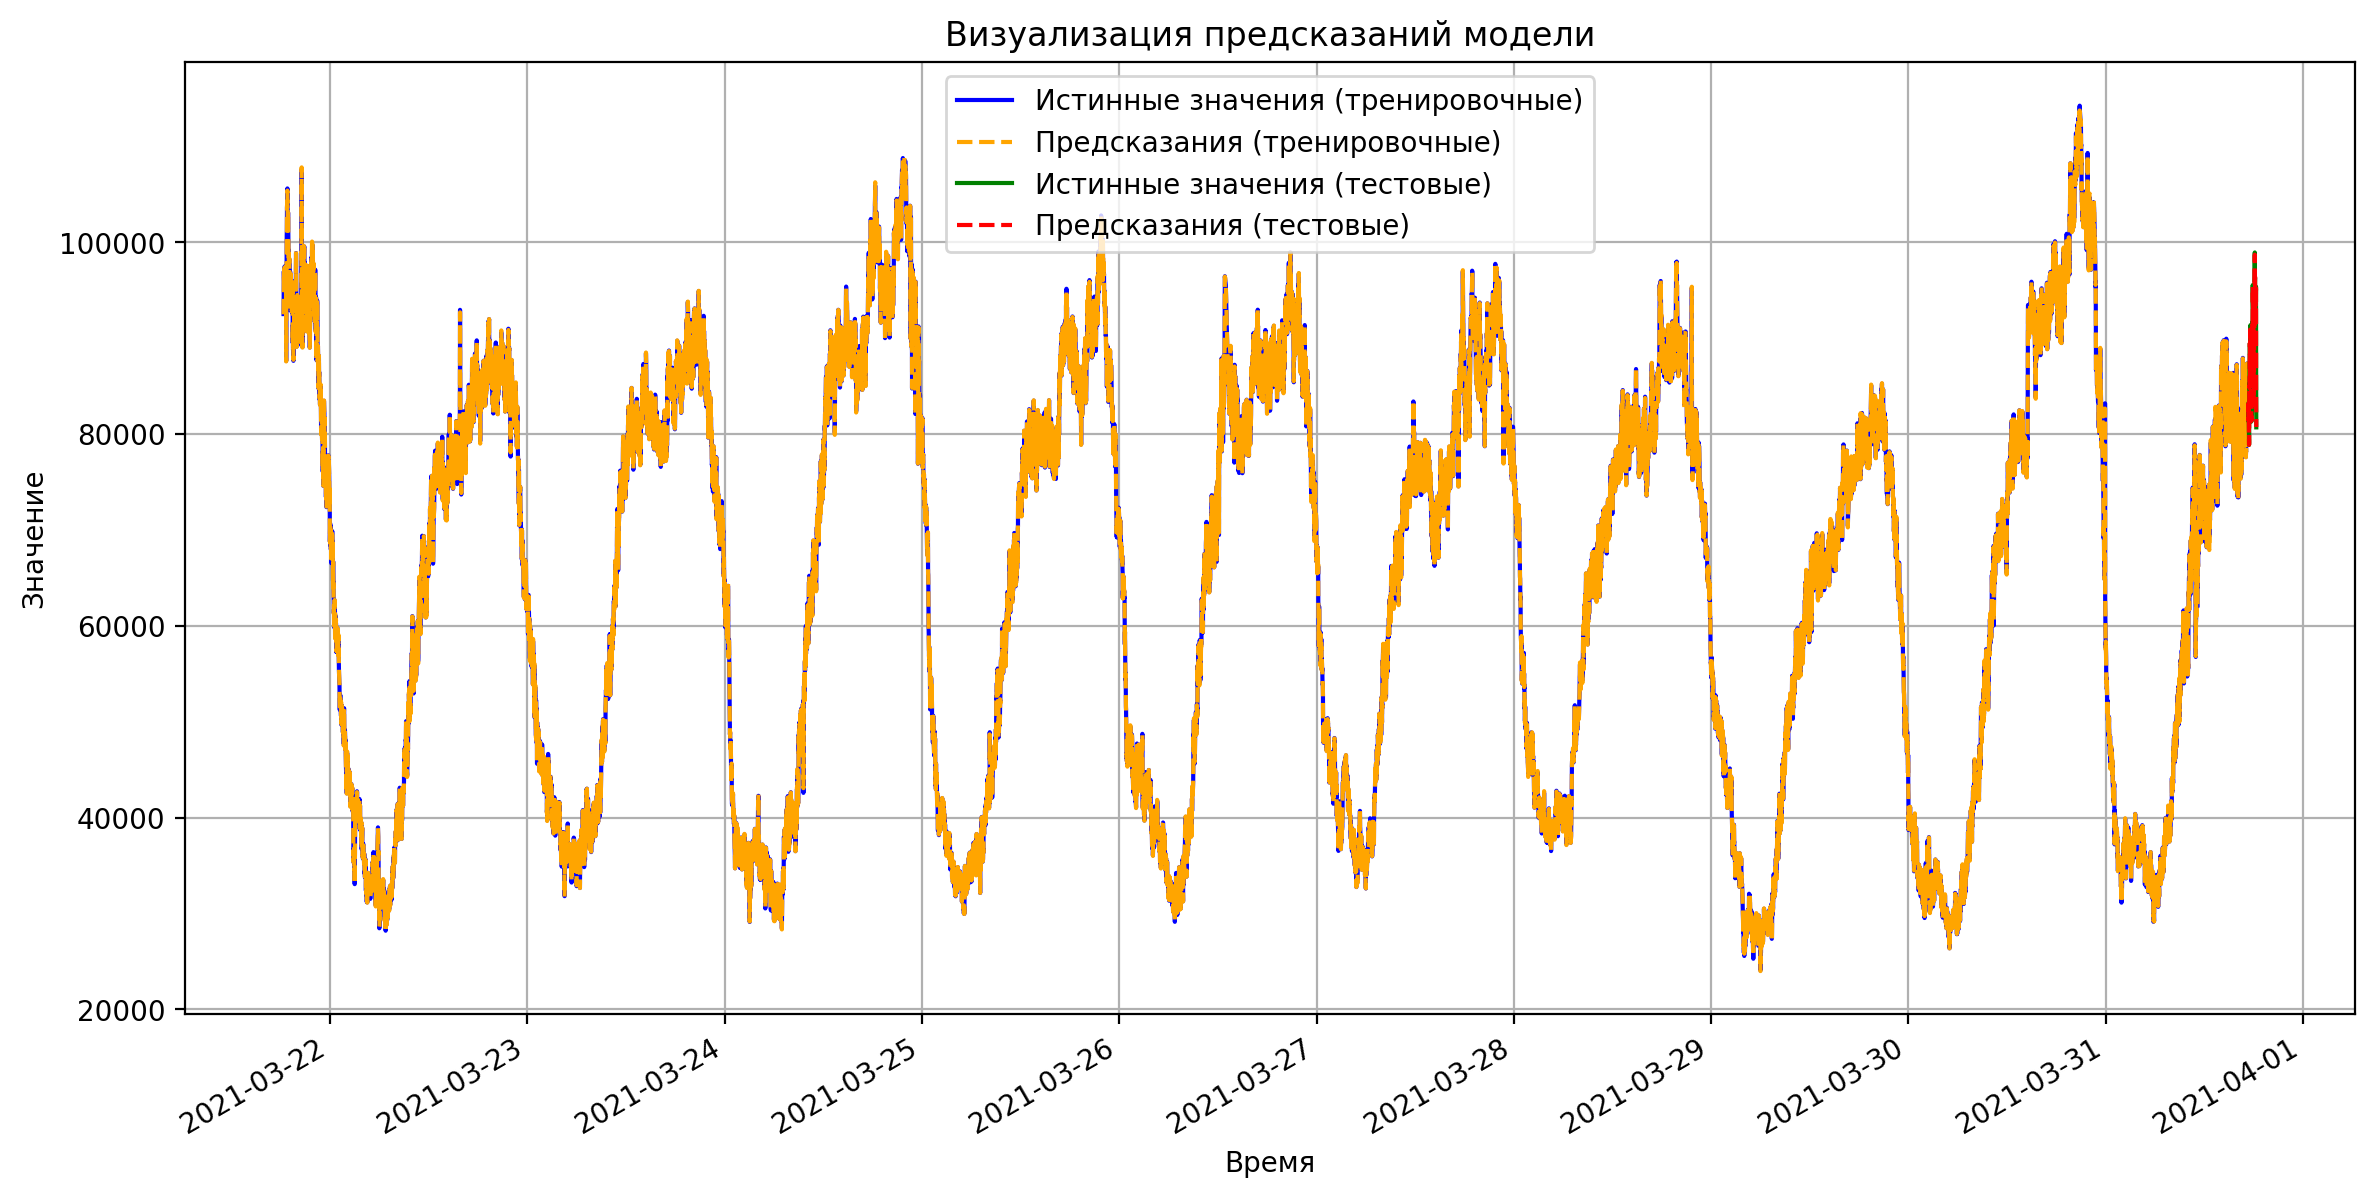

In [ ]:
# Построение графика
plt.figure(figsize=(14, 7))

# Получаем временные метки для обучающих данных
train_time = data_filled['ds'].iloc[:-60]

# Получаем временные метки для тестовых данных
test_time = data_filled['ds'].iloc[-60:]

# Истинные значения на тренировочной выборке
plt.plot(train_time, y_train_important.values, label='Истинные значения (тренировочные)', color='blue')

# Предсказания на тренировочной выборке
plt.plot(train_time, y_train_pred, label='Предсказания (тренировочные)', color='orange', linestyle='--')

# Истинные значения на тестовой выборке
plt.plot(test_time, y_test_important.values, label='Истинные значения (тестовые)', color='green')

# Предсказания на тестовой выборке
plt.plot(test_time, y_test_pred_important, label='Предсказания (тестовые)', color='red', linestyle='--')

# Настройки графика
plt.title("Визуализация предсказаний модели")
plt.xlabel("Время")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)

# Автоматическое форматирование меток оси X
plt.gcf().autofmt_xdate()

# Отображение графика
plt.show()

### Прогноз на следующие сутки и расчет MAPE

In [ ]:
# Отбираем данные только с важными признаками
X_train_important = X_new.iloc[:-1440]
y_train_important = y.iloc[:-1440]
X_test_important = X_new.iloc[-1440:]
y_test_important = y.iloc[-1440:]


# Функция для оптимизации
def objective(trial):
    # Подбор гиперпараметров
    iterations = trial.suggest_int('iterations', 900, 3300, step=100)
    depth = trial.suggest_int('depth', 5, 10, step=1)
    learning_rate = trial.suggest_float('learning_rate', 0.03, 0.07, step=0.005)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 3, 10, step=1)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.5, 0.9, step=0.1)
    subsample = trial.suggest_float('subsample', 0.6, 0.9, step=0.1)

    # Кросс-валидация с временными рядами
    tscv = TimeSeriesSplit(n_splits=5)
    cv_mape_scores = []

    for train_index, val_index in tscv.split(X_train_important):
        X_train_fold, X_val_fold = X_train_important.iloc[train_index], X_train_important.iloc[val_index]
        y_train_fold, y_val_fold = y_train_important.iloc[train_index], y_train_important.iloc[val_index]

        # Обучение модели
        model = CatBoostRegressor(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=l2_leaf_reg,
            bagging_temperature=bagging_temperature,
            random_seed=42,
            verbose=0
        )
        model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), verbose=0)

        # Оценка на валидационной выборке
        y_val_pred = model.predict(X_val_fold)
        cv_mape_scores.append(mean_absolute_percentage_error(y_val_fold, y_val_pred))

    # Средний MAPE на кросс-валидации
    mape_validation = np.mean(cv_mape_scores)

    # Предсказание на тестовой выборке
    model.fit(X_train_important, y_train_important, verbose=0)
    y_test_pred_important = model.predict(X_test_important)
    mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)

    # Взвешенная метрика
    return mape_validation

# Оптимизация гиперпараметров с Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Лучшие гиперпараметры
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)

[I 2025-03-01 07:02:24,367] A new study created in memory with name: no-name-00febb58-53c6-4978-8d74-f817b4738f02
[I 2025-03-01 07:03:31,671] Trial 0 finished with value: 0.0028837903297747845 and parameters: {'iterations': 1900, 'depth': 8, 'learning_rate': 0.07, 'l2_leaf_reg': 3.0, 'bagging_temperature': 0.8, 'subsample': 0.7}. Best is trial 0 with value: 0.0028837903297747845.
[I 2025-03-01 07:04:12,197] Trial 1 finished with value: 0.003099055534514982 and parameters: {'iterations': 1300, 'depth': 8, 'learning_rate': 0.034999999999999996, 'l2_leaf_reg': 3.0, 'bagging_temperature': 0.7, 'subsample': 0.9}. Best is trial 0 with value: 0.0028837903297747845.
[I 2025-03-01 07:08:03,077] Trial 2 finished with value: 0.0030288406566511615 and parameters: {'iterations': 3200, 'depth': 10, 'learning_rate': 0.03, 'l2_leaf_reg': 9.0, 'bagging_temperature': 0.7, 'subsample': 0.9}. Best is trial 0 with value: 0.0028837903297747845.
[I 2025-03-01 07:09:29,179] Trial 3 finished with value: 0.0034

Лучшие гиперпараметры: {'iterations': 3300, 'depth': 6, 'learning_rate': 0.065, 'l2_leaf_reg': 4.0, 'bagging_temperature': 0.8, 'subsample': 0.9}


In [ ]:
# Оценка модели с лучшими гиперпараметрами
model = CatBoostRegressor(
    iterations=best_params['iterations'],
    depth=best_params['depth'],
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    bagging_temperature=best_params['bagging_temperature'],
    subsample=best_params['subsample'],
    random_seed=42,
    early_stopping_rounds=50,
    verbose=0
)
model.fit(X_train_important, y_train_important, verbose=0)

# Средний MAPE на кросс-валидации
y_train_pred = model.predict(X_train_important)
mape_cv = mean_absolute_percentage_error(y_train_important, y_train_pred)
print("Средний MAPE на кросс-валидации:", mape_cv)

# MAPE на последней минуте
y_test_pred_important = model.predict(X_test_important)
mape_test = mean_absolute_percentage_error(y_test_important, y_test_pred_important)
print("MAPE на сутки с оптимизированными гиперпараметрами:", mape_test)

Средний MAPE на кросс-валидации: 0.001339120722994827
MAPE на сутки с оптимизированными гиперпараметрами: 0.0038051216947930923


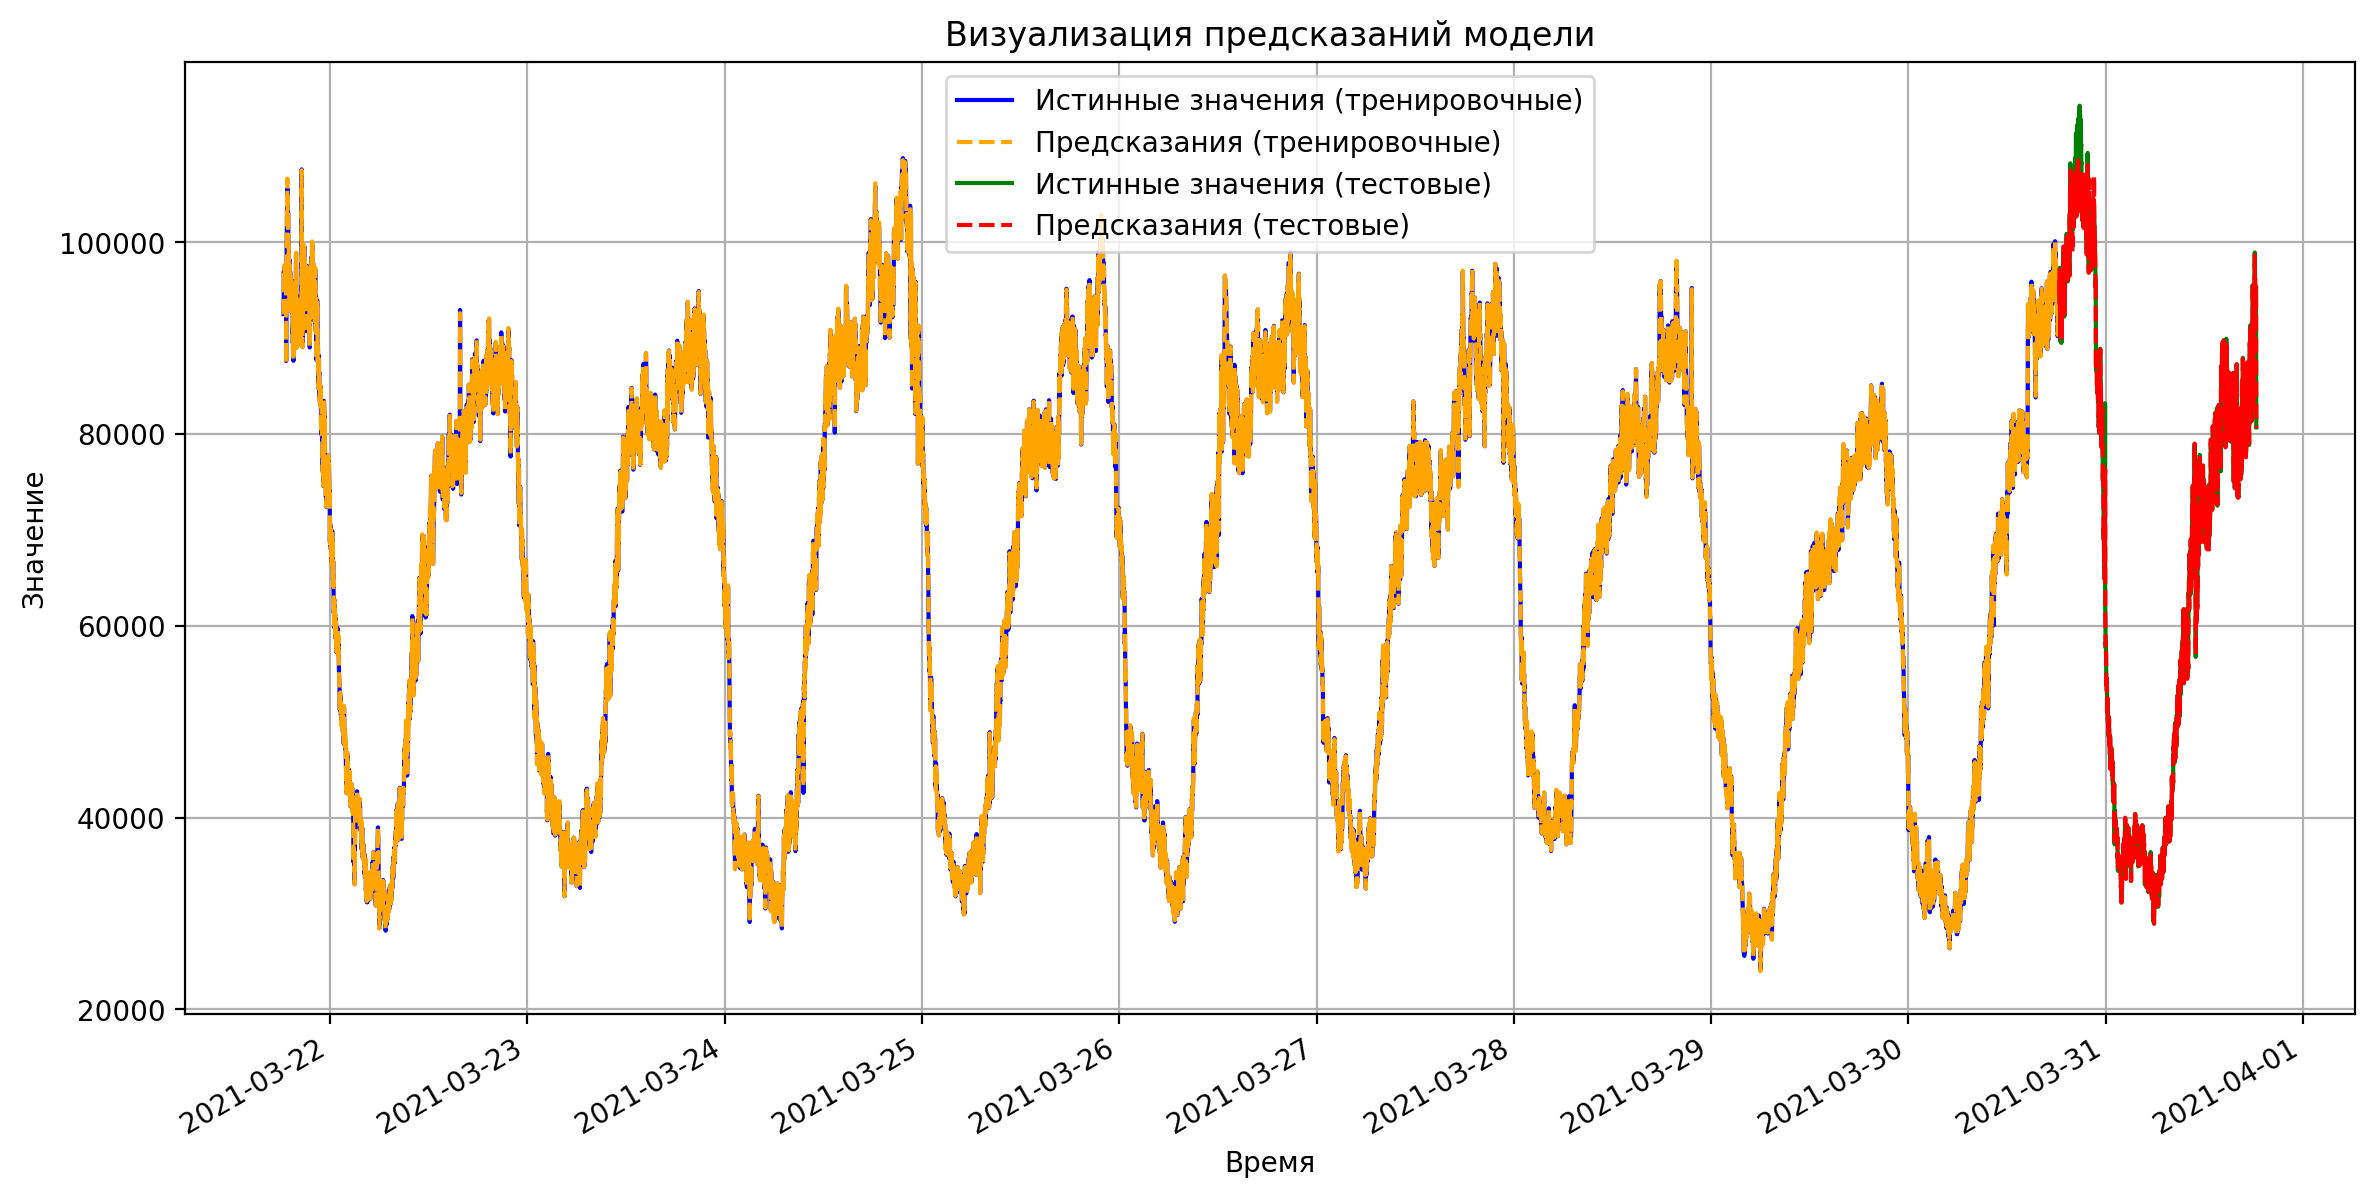

In [ ]:
# Построение графика
plt.figure(figsize=(14, 7))

# Получаем временные метки для обучающих данных
train_time = data_filled['ds'].iloc[:-1440]

# Получаем временные метки для тестовых данных
test_time = data_filled['ds'].iloc[-1440:]

# Истинные значения на тренировочной выборке
plt.plot(train_time, y_train_important.values, label='Истинные значения (тренировочные)', color='blue')

# Предсказания на тренировочной выборке
plt.plot(train_time, y_train_pred, label='Предсказания (тренировочные)', color='orange', linestyle='--')

# Истинные значения на тестовой выборке
plt.plot(test_time, y_test_important.values, label='Истинные значения (тестовые)', color='green')

# Предсказания на тестовой выборке
plt.plot(test_time, y_test_pred_important, label='Предсказания (тестовые)', color='red', linestyle='--')

# Настройки графика
plt.title("Визуализация предсказаний модели")
plt.xlabel("Время")  # Изменено название оси X
plt.ylabel("Значение")
plt.legend()
plt.grid(True)

# Автоматическое форматирование меток оси X
plt.gcf().autofmt_xdate()

# Отображение графика
plt.show()


### Оценка результатов прогнозирования разных моделей на разные периоды (1 минута, 1 час и 1 сутки).

В качестве базовой модели для выявления выбросов и аномалий использовали модель Prophet.


После отбора дополнительных признаков с помощью RFECV для прогноза на 1 минуту применили следующие модели:

- Модель Prophet c дополнительными регрессорами: MAPE = 0.006232;
- Модель LGBMRegressor с подбором гиперпараметров с помощью OPTUNA: MAPE = 0.0002973
- Модель CatBoostRegressor с подбором гиперпараметров с помощью OPTUNA: MAPE = 0.0002347

Для прогнозирования количества запросов на следующую минуту модель CatBoostRegressor с подобранными гиперпараметрами показала наилучшие результаты по метрике MAPE.

Для прогноза на час и сутки была выбрана модель CatBoostRegressor.


Результаты качества модели CatBoostRegressor на всех периодах прогнозирования после подбора гиперпараметров с помощью Optuna.
MAPE:
- следующая минута: 0.0002347
- следующий час: 0.0012529
- следующие сутки: 0.00380


**Выводы:**

Для прогнозирования количества запросов на следующую минуту, час и сутки модель CatBoostRegressor с подобранными гиперпараметрами показала наилучшие результаты по метрике MAPE.
Модель LGBMRegressor также показала хорошие результаты после отбора важных признаков.
Модель Prophet может быть использована для базового прогнозирования и анализа тренда и сезонности, но для более точных прогнозов на короткие периоды рекомендуется использовать CatBoostRegressor или LGBMRegressor.
